<a href="https://colab.research.google.com/github/leandromids/Multiprocessing-tuts/blob/master/fraud_detection_batch_vs_streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Detecção de fraude - Modelos batch vs. Modelos streaming (IEEE-CIS)**
____
### **Área de Concentração:** Cibersegurança / Segurança da Informação.
### **Linha de Pesquisa:** Inteligência de Ameaças e Detecção de Fraudes Digitais.

### **Palavras-chave formais:** *Cyber Fraud Detection; Payment Security; Stream Learning; Concept Drift; Adversarial Robustness.*
____
### **Entrega acadêmica:** Avaliação da degradação temporal dos modelos preditivos e comparação de eficiência computacional vs. taxa de falsos alarmes.

### **Projeto de Mestrado — UnB**

>### **Discente:** Leandro Martins Inácio dos Santos
>### **Docente:** Prof. Dr. André Luiz Marques Serrano
>### **Curso:** PPEE/UnB — Engenharia Elétrica


## **Resumo**

### Este trabalho comparou modelos batch (Frameeork Sci-kit Learn: XGBoost e LightGBM) e aprendizado em fluxo (Framework River: ADF-Adaptive Random Forest) na detecção de fraude sob *concept drift* (Drift sinalizado com ADWIN), ultilizando o [dataset IEEE-CIS](https://www.kaggle.com/datasets/lnasiri007/ieeecis-fraud-detection) com marcação temporal hipotética real time e atraso emírico-realista de rótulo.

### A deriva temporal foi confirmada em três evidências independentes: o aumento da taxa de fraude entre a partição de warm-up e a de fluxo, a oscilação da fraude ao longo das semanas e a queda sistemática do PR-AUC dos modelos congelados. Os detectores ADWIN sinalizaram mudança em instantes que coincidem com os trechos de degradação, oferecendo prova direta e datada do fenômeno.

### O resultado central é que, no cenário avaliado, os modelos batch superaram o streaming com significância estatística, embora todos degradem com o tempo. O aprendizado em fluxo parte de um desempenho baixo — efeito da partida fria — e cresce ao longo do fluxo, sem alcançar os modelos estáticos, mas com a menor latência por transação. O retreino periódico e o retreino disparado por drift não superaram o modelo congelado de forma significativa, achado que se atribui principalmente ao viés introduzido pelo atraso de rótulo.

### A principal contribuição conceitual é reconhecer que esse atraso depende do meio de pagamento: no cartão o prejuízo demora a ser percebido, enquanto no PIX ele é imediato. Isso delimita a validade externa dos resultados para o contexto brasileiro e aponta como trabalho futuro a avaliação sobre dados com PIX, além da análise de sensibilidade ao atraso e do efeito da capacidade do modelo em fluxo.

# 1 - Análise Exploratória dos dados do IEEE-CIS Fraud Detection

### Dataset *IEEE-CIS Fraud Detection* (Kaggle), Foco nas questões que orientam a pesquisa sobre **detecção de fraude em fluxo (streaming) vs. modelos estáticos (batch)**.

### **Perguntas que este seção 1 responde:**
### 1. Qual a estrutura das duas tabelas (transações e identidade) e como se conectam?
### 2. Qual a taxa de fraude geral? (desbalanceamento)
### 3. A **presença de dados de identidade** é informativa? A taxa de fraude muda entre quem tem e quem não tem identidade?
### 4. Qual o padrão de **valores ausentes**?
### 5. Como o **tempo** é representado? Há evidência de deriva temporal (concept drift)?

> **Datasets:**  `train_transaction.csv` e `train_identity.csv`</p>
> Os datasets de teste do Kaggle **não possui rótulo**, por isso toda a
> análise usa apenas o conjunto de **treino**.

## 1.1 Configuração do ambiente

In [1]:
# No Colab, estas bibliotecas já vêm instaladas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

## 1.2 Carregamento dos dados
Upload do Google Drive

In [2]:
# --- Google Drive ---
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/'

df_trans = pd.read_csv(BASE + 'train_transaction.csv') #Dados das transações
df_id    = pd.read_csv(BASE + 'train_identity.csv')    #Dados das identidades

print('Transacoes:', df_trans.shape)
print('Identidade :', df_id.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transacoes: (590540, 394)
Identidade : (144233, 41)


## 1.3 Estrutura das duas tabelas

### A tabela de **transações** contém o rótulo `isFraud`, o valor, dados do cartão, endereço e as grandes famílias de variáveis anonimizadas (C, D, M, V). A tabela de **identidade** traz dispositivo, navegador e rede. As duas se conectam pela chave `TransactionID`.

In [3]:
print('Colunas de transacoes:', df_trans.shape[1])
print('Colunas de identidade :', df_id.shape[1])
print('Total de colunas       :', df_trans.shape[1] + df_id.shape[1] - 1, '(descontando a chave compartilhada)')

# Familias de variaveis anonimizadas na tabela de transacoes
familias = {L: [c for c in df_trans.columns if c.startswith(L) and c[len(L):].isdigit()]
            for L in ['C', 'D', 'M', 'V']}
for L, cols in familias.items():
    print(f'Familia {L}: {len(cols)} colunas')

Colunas de transacoes: 394
Colunas de identidade : 41
Total de colunas       : 434 (descontando a chave compartilhada)
Familia C: 14 colunas
Familia D: 15 colunas
Familia M: 9 colunas
Familia V: 339 colunas


### **Muitas features (Colunas) é necessário avaliar uma redução de dimencionalidade**

## 1.4 Taxa de fraude geral (desbalanceamento)

Taxa de fraude geral: 3.4990%
isFraud
0    569877
1     20663
Name: count, dtype: int64


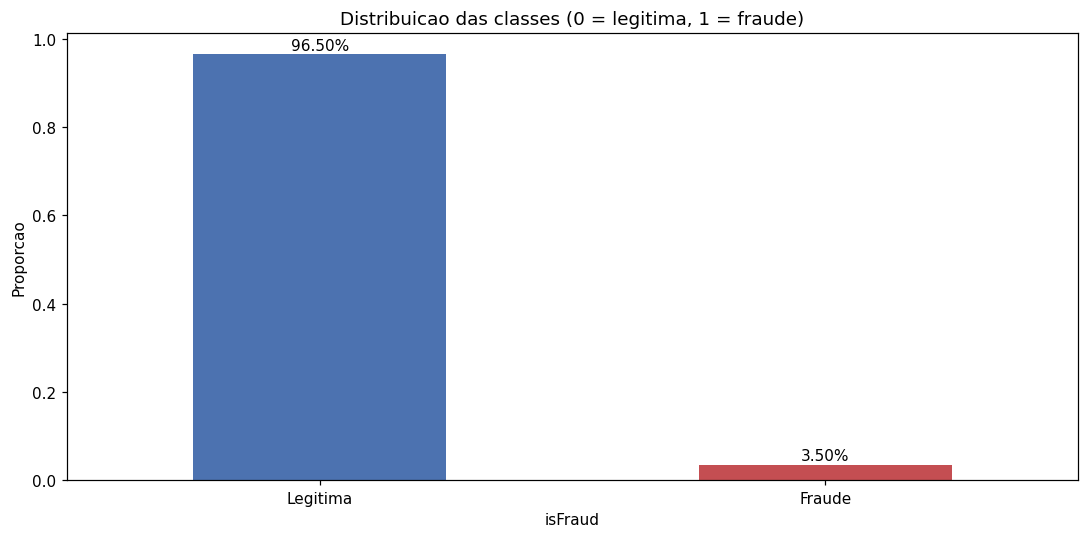

In [4]:
taxa = df_trans['isFraud'].mean()
print(f'Taxa de fraude geral: {taxa:.4%}')
print(df_trans['isFraud'].value_counts())

ax = df_trans['isFraud'].value_counts(normalize=True).plot(kind='bar', color=['#4C72B0', '#C44E52'])
ax.set_title('Distribuicao das classes (0 = legitima, 1 = fraude)')
ax.set_ylabel('Proporcao'); ax.set_xticklabels(['Legitima', 'Fraude'], rotation=0)
for i, v in enumerate(df_trans['isFraud'].value_counts(normalize=True)):
    ax.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.tight_layout(); plt.show()

## 1.5 A presença de identidade é informativa?

### Hipótese levantada na concepção do projeto: nem toda transação tem registro de identidade, e **essa ausência não é aleatória** — ela se correlaciona com o risco de fraude. Vamos criar a flag `tem_identidade` e comparar a taxa de fraude entre os dois grupos (técnica de *missing indicator*).

Transacoes COM identidade: 24.42%
Transacoes SEM identidade: 75.58%

                    mean   count
Sem identidade  0.020939  446307
Com identidade  0.078470  144233


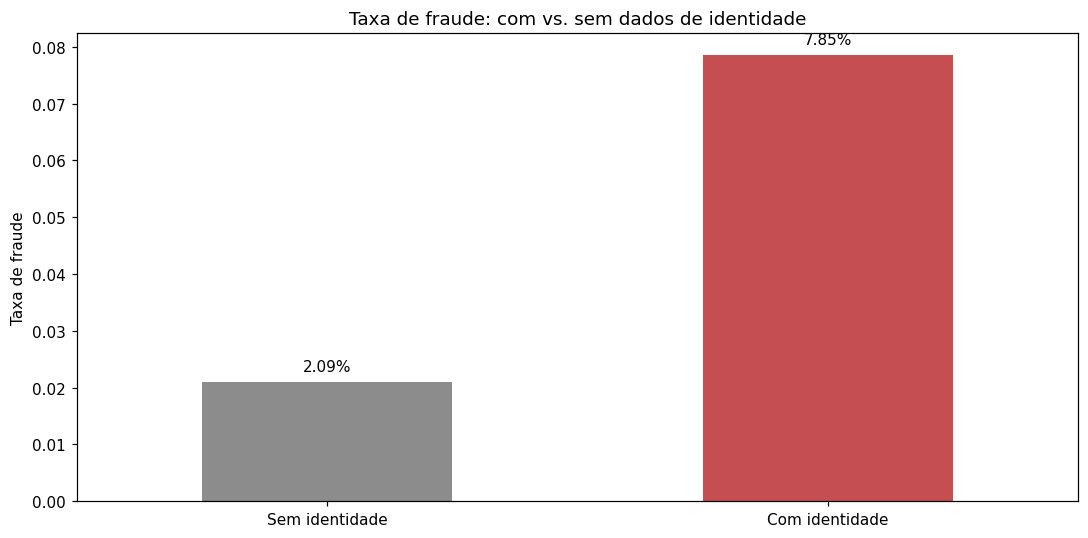

In [5]:
ids_com_identidade = set(df_id['TransactionID'])
df_trans['tem_identidade'] = df_trans['TransactionID'].isin(ids_com_identidade).astype(int)

cobertura = df_trans['tem_identidade'].mean()
print(f'Transacoes COM identidade: {cobertura:.2%}')
print(f'Transacoes SEM identidade: {1-cobertura:.2%}')
print()

taxa_por_grupo = df_trans.groupby('tem_identidade')['isFraud'].agg(['mean', 'count'])
taxa_por_grupo.index = ['Sem identidade', 'Com identidade']
print(taxa_por_grupo)

ax = taxa_por_grupo['mean'].plot(kind='bar', color=['#8C8C8C', '#C44E52'])
ax.set_title('Taxa de fraude: com vs. sem dados de identidade')
ax.set_ylabel('Taxa de fraude'); ax.set_xticklabels(taxa_por_grupo.index, rotation=0)
for i, v in enumerate(taxa_por_grupo['mean']):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')
plt.tight_layout(); plt.show()

### **Leitura do resultado:** a taxa de fraude no grupo *com identidade* é várias vezes maior que no grupo *sem identidade*, isso confirma que a simples presença do bloco de identidade carrega sinal de risco — justificando o uso da flag `tem_identidade` como variável do modelo, e não o descarte das transações sem identidade.

## 1.6 Valores ausentes

In [6]:
missing = df_trans.isna().mean().sort_values(ascending=False)
print('Colunas com mais valores ausentes:')
print((missing[missing > 0].head(15) * 100).round(1).astype(str) + '%')
print(f'\nColunas com algum valor ausente: {(missing > 0).sum()} de {len(missing)}')

Colunas com mais valores ausentes:
dist2    93.6%
D7       93.4%
D13      89.5%
D14      89.5%
D12      89.0%
D6       87.6%
D8       87.3%
D9       87.3%
V153     86.1%
V163     86.1%
V162     86.1%
V161     86.1%
V158     86.1%
V157     86.1%
V156     86.1%
dtype: object

Colunas com algum valor ausente: 374 de 395


## 1.7 Estrutura temporal (porta de entrada para o estudo de drift)

### O dataset não traz data de calendário: o tempo é dado por `TransactionDT`, um deslocamento em **segundos** a partir de um marco inicial arbitrário. Preservar essa ordem é essencial para evitar vazamento temporal e para estudar a deriva de conceito.

TransactionDT -- min: 86,400  max: 15,811,131
Periodo coberto: ~182 dias


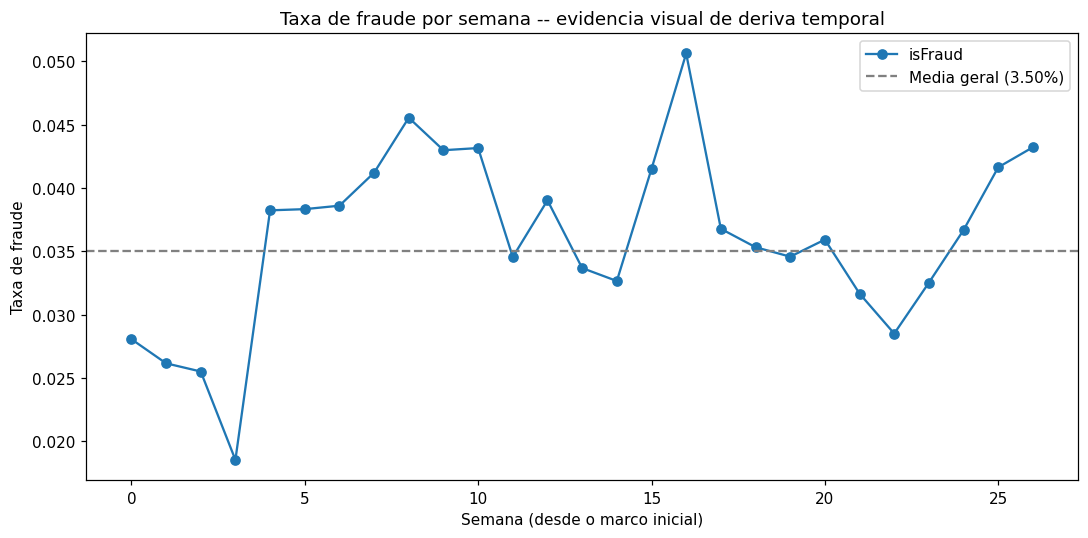

In [7]:
dt = df_trans['TransactionDT']
print(f'TransactionDT -- min: {dt.min():,}  max: {dt.max():,}')
print(f'Periodo coberto: ~{(dt.max() - dt.min()) / 86400:.0f} dias')

# Taxa de fraude ao longo do tempo (janelas semanais)
df_trans['semana'] = (df_trans['TransactionDT'] // (7 * 86400)).astype(int)
fraude_semana = df_trans.groupby('semana')['isFraud'].mean()

ax = fraude_semana.plot(marker='o')
ax.set_title('Taxa de fraude por semana -- evidencia visual de deriva temporal')
ax.set_xlabel('Semana (desde o marco inicial)'); ax.set_ylabel('Taxa de fraude')
ax.axhline(taxa, color='gray', ls='--', label=f'Media geral ({taxa:.2%})')
ax.legend(); plt.tight_layout(); plt.show()

### **Leitura do resultado:** oscilações sistemáticas da taxa de fraude ao longo das semanas são evidência empírica de *concept drift* — exatamente o fenômeno que o modelo estático sofre e que o aprendizado em fluxo busca acompanhar.

## 1.8 Análise de correlação e redundância dos dados

### - **1.8.1** Construção de *mapa de calor* da correlação entre as variáveis família V (maior grupo, com 339 colunas) para verificar existência de **blocos redundantes** — argumento
###  visual que pode justificar a redução de dimensionalidade;
### - **1.8.2** Quantificando a redundância: pares de variáveis V altamente correlacionadas.
### - **1.8.3** um *ranking* das variáveis mais associadas ao rótulo `isFraud`, apontando candidatas fortes para o modelo.

### 1.8.1 Mapa de calor da correlação entre as variáveis da família V (339 de 434 Variáveis)

Variaveis da familia V: 339


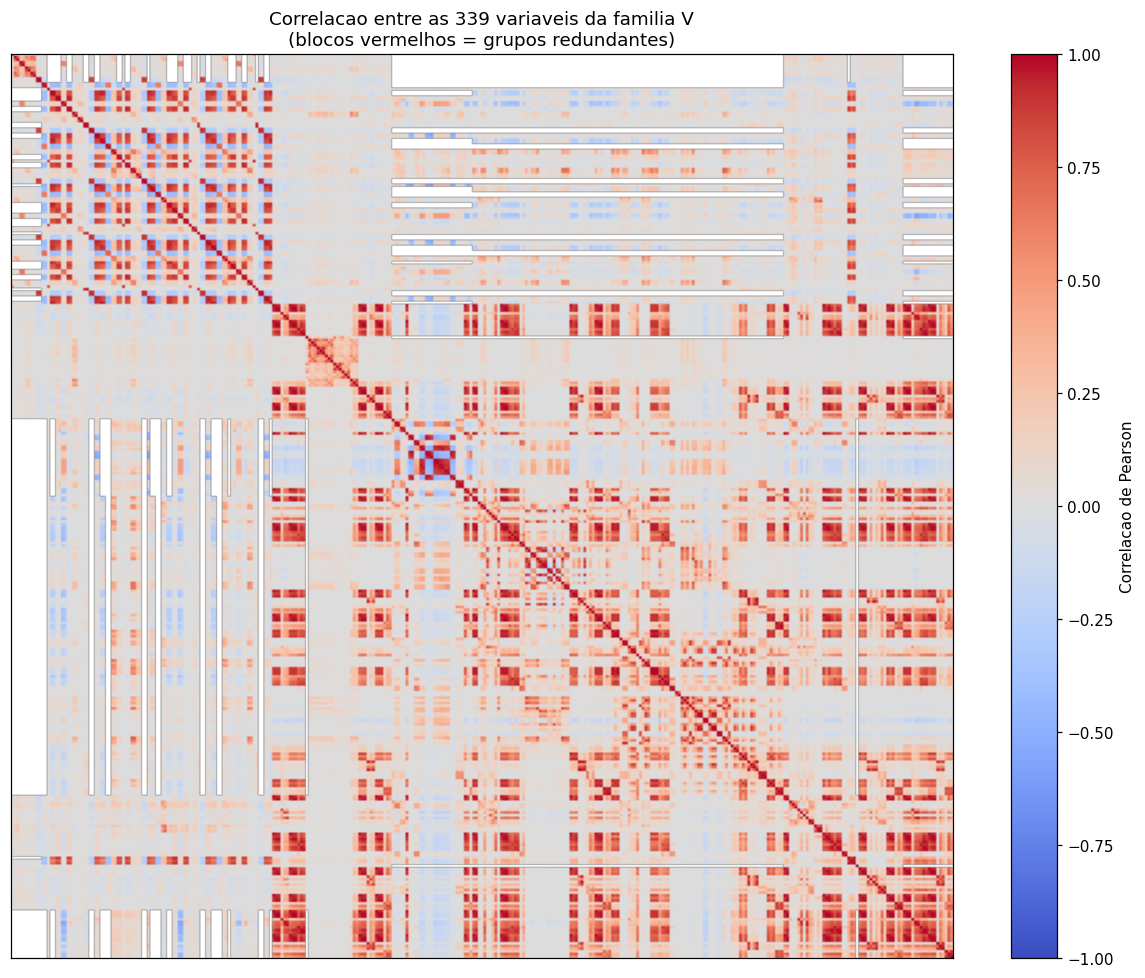

In [8]:
import numpy as np
import matplotlib.pyplot as plt

v_cols = [c for c in df_trans.columns if c.startswith('V') and c[1:].isdigit()]
print(f'Variaveis da familia V: {len(v_cols)}')

# Correlacao de Pearson entre as variaveis V (ignora ausentes par a par)
corr_v = df_trans[v_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_v.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Correlacao entre as 339 variaveis da familia V\n(blocos vermelhos = grupos redundantes)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, label='Correlacao de Pearson')
plt.tight_layout(); plt.show()

### **Leitura do resultado:** os blocos **quadrados avermelhados** ao longo da diagonal são grupos de **variáveis V fortemente correlacionadas entre si** — ou seja, redundantes. Isso sustenta, na metodologia, uma etapa de redução de dimensionalidade (agrupamento por correlação ou PCA incremental) antes da modelagem, aplicada **igual** aos dois paradigmas (batch e streaming) para manter a comparação justa.

### E repara também nas **faixas brancas**, aquelas linhas e colunas vazias. São variáveis que têm tanto valor ausente que a **correlação nem pôde ser calculada**.</p>

### 1.8.2 Quantificando a redundância: pares de variáveis V altamente correlacionadas

In [9]:
# Conta quantos pares de variaveis V tem correlacao absoluta acima de limiares
abs_corr = corr_v.abs()
mask = np.triu(np.ones(abs_corr.shape, dtype=bool), k=1)  # so a parte de cima, sem a diagonal
pares = abs_corr.where(mask)

for limiar in [0.9, 0.95, 0.99]:
    n = (pares > limiar).sum().sum()
    print(f'Pares de variaveis V com |correlacao| > {limiar}: {n}')

total_pares = mask.sum()
print(f'\nTotal de pares possiveis: {total_pares:,}')

Pares de variaveis V com |correlacao| > 0.9: 1333
Pares de variaveis V com |correlacao| > 0.95: 541
Pares de variaveis V com |correlacao| > 0.99: 139

Total de pares possiveis: 57,291


### **Leitura do resultado:** um número alto de pares acima de 0,95 confirma numericamente a redundância que o mapa de calor mostra visualmente — argumento quantitativo para a redução de dimensionalidade.

### 57 mil pares possíveis de variáveis V:</p> I) **1.333 pares têm correlação acima de 90%**; </p> II) **541 pares passam de 95%**;e </p> III) **139 pares são praticamente idênticos, com correlação acima de 99%.**

### Uma redução de dimensionalidade sugerida restringi-se à remoção de variáveis  da família V redundantes entre si (|ρ| > 0,95), preservando-se, em cada grupo redundante, uma representante. Esse corte tende a ter efeito assimétrico entre os paradigmas. Modelos batch baseados em boosting de árvores são, em geral, robustos a variáveis altamente correlacionadas, razão pela qual não se espera perda relevante de desempenho preditivo. Nos modelos online baseados em árvores de Hoeffding, por outro lado, o custo computacional por transação cresce com o número de variáveis, e pares quase equivalentes retardam as decisões de divisão. Como o mesmo conjunto final é aplicado a ambos os paradigmas, com a decisão calculada exclusivamente na janela de aquecimento, **a redução não favorece nenhum deles e evita que a comparação passe a refletir a tolerância à alta dimensionalidade, em vez da capacidade de adaptação à deriva de conceito**. Para verificar empiricamente a primeira premissa, o modelo XGBoost congelado foi treinado com o conjunto completo (432 variáveis) e com o conjunto reduzido (290 variáveis); **[resultado do teste]**.

### 1.8.3 Ranking das variáveis mais associadas ao rótulo `isFraud`

Top 20 variaveis mais correlacionadas com isFraud (|correlacao|):
  V257          +0.3831
  V246          +0.3669
  V244          +0.3641
  V242          +0.3606
  V201          +0.3280
  V200          +0.3188
  V189          +0.3082
  V188          +0.3036
  V258          +0.2972
  V45           +0.2818
  V158          +0.2781
  V156          +0.2760
  V149          +0.2733
  V228          +0.2689
  V44           +0.2604
  V86           +0.2518
  V87           +0.2517
  V170          +0.2498
  V147          +0.2429
  V52           +0.2395


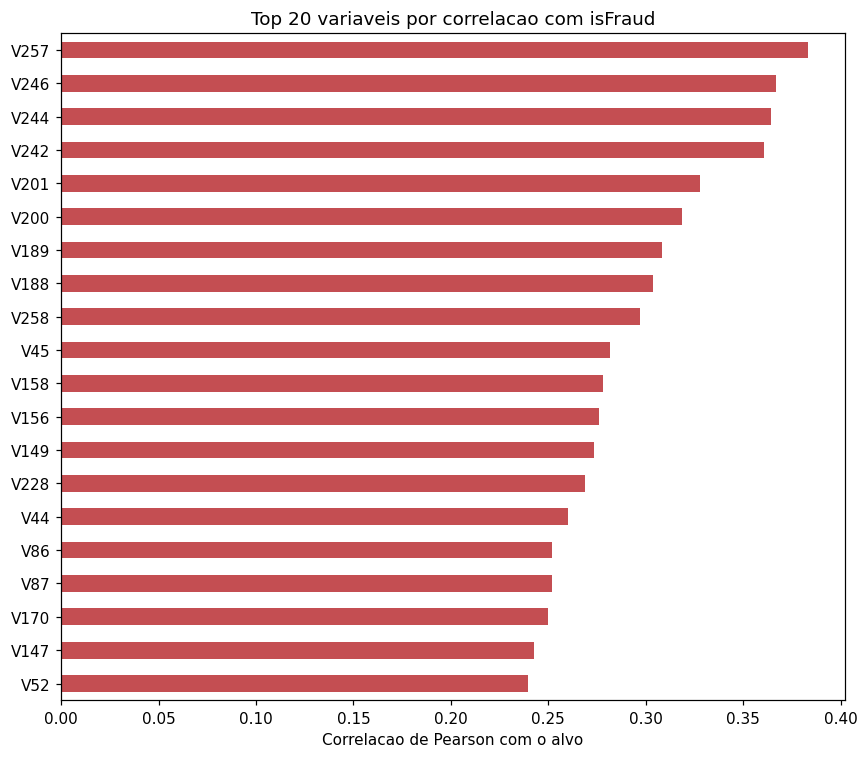

In [10]:
# Correlacao de cada variavel numerica com o alvo isFraud (candidatas a preditoras fortes)
num_cols = df_trans.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ['isFraud', 'TransactionID', 'TransactionDT', 'semana', 'tem_identidade']]

corr_alvo = df_trans[num_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
top = corr_alvo.abs().sort_values(ascending=False).head(20)

print('Top 20 variaveis mais correlacionadas com isFraud (|correlacao|):')
for nome in top.index:
    print(f'  {nome:12s}  {corr_alvo[nome]:+.4f}')

ax = corr_alvo[top.index].sort_values().plot(kind='barh', figsize=(8, 7),
                                             color=(corr_alvo[top.index].sort_values() > 0).map({True:'#C44E52', False:'#4C72B0'}))
ax.set_title('Top 20 variaveis por correlacao com isFraud')
ax.set_xlabel('Correlacao de Pearson com o alvo')
plt.tight_layout(); plt.show()

### **Leitura do resultado:** correlação linear com o alvo é um indício, **não** prova de importância — relações não lineares escapam dela. Por isso a importância definitiva virá do modelo (ex.: **SHAP** sobre o XGBoost), no notebook do baseline. Ainda assim, este ranking já aponta variáveis candidatas e ajuda a interpretar o dataset.

# 2 - Preparação dos dados para modelagem
## Divisão Temporal e Redução de Variáveis (blindada contra vazamento)

### Preparando os dados para a comparação **batch vs. streaming**, respeitando rigorosamente a ordem temporal.</p>
### **Princípio central (anti-vazamento / *data leakage*):** nenhuma estatística ou decisão pode usar informação de transações que, no tempo, ainda não ocorreram. Toda decisão de pré-processamento e seleção é **aprendida apenas na janela de aquecimento (warm-up)** e depois **aplicada** ao fluxo de avaliação, sem recalcular com o futuro.</p>
### **Universo de dados:** *warm-up* = primeiros 30% no tempo; *fluxo de avaliação* = 70% restantes.

## 2.1 Carregamento e junção das tabelas

In [103]:
from pathlib import Path

pasta = Path("/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/")

for arquivo in sorted(pasta.rglob("*")):
    if arquivo.is_file() and arquivo.suffix.lower() in {
        ".parquet", ".csv", ".zip"
    }:
        print(arquivo)

/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/preparado/features_finais.csv
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/preparado/stream.parquet
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/preparado/warmup.parquet
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/processed/dataset_20261003T221341_362607/ieee_cis_train.parquet
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/processed/dataset_20261003T221341_362607/stream.parquet
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/processed/dataset_20261003T221341_362607/warmup.parquet
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/processed/missing_values.csv
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/processed/weekly_eda.csv
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/sample_submission.csv
/content/drive/MyDri

In [104]:
import numpy as np
import pandas as pd

df_trans = pd.read_csv(BASE + 'train_transaction.csv')
df_id    = pd.read_csv(BASE + 'train_identity.csv')

# Flag de identidade ANTES do merge (presenca de identidade e informativa)
ids_com_identidade = set(df_id['TransactionID'])
df = df_trans.merge(df_id, on='TransactionID', how='left')
df['tem_identidade'] = df['TransactionID'].isin(ids_com_identidade).astype(int)

print('Shape apos merge:', df.shape)

Shape apos merge: (590540, 435)


## 2.2 Ordenação e corte temporal (primeira blindagem)

### Proibido embaralhar. Ordenamos por `TransactionDT` e cortamos por tempo: o warm-up nunca contém uma transação posterior às que serão avaliadas no fluxo.

In [105]:
# PROIBIDO shuffle: ordena estritamente pelo tempo
df = df.sort_values('TransactionDT').reset_index(drop=True)

WARMUP_FRAC = 0.30
corte = int(len(df) * WARMUP_FRAC)

warmup = df.iloc[:corte].copy()      # janela de aquecimento (passado)
stream = df.iloc[corte:].copy()      # fluxo de avaliacao (futuro)

print(f'Warm-up: {len(warmup):,} transacoes  | fraude: {warmup["isFraud"].mean():.2%}')
print(f'Fluxo  : {len(stream):,} transacoes  | fraude: {stream["isFraud"].mean():.2%}')
print(f'Tempo warm-up: ate {warmup["TransactionDT"].max()/86400:.0f} dias; '
      f'fluxo comeca em {stream["TransactionDT"].min()/86400:.0f} dias')

Warm-up: 177,162 transacoes  | fraude: 2.84%
Fluxo  : 413,378 transacoes  | fraude: 3.78%
Tempo warm-up: ate 45 dias; fluxo comeca em 45 dias


## 2.3 Redução de variáveis no warm-up (segunda blindagem)

### Três etapas, todas calculadas **apenas sobre o warm-up**. As listas de colunas a manter/remover são a "regra" aprendida no passado; depois aplicamos a mesma regra ao fluxo.

### Perfeito, e olha que resultado bonito pra sua pesquisa! Está tudo exatamente como a teoria previa.

### O aquecimento ficou em **2,84%** de fraude, e o fluxo em **3,78%**. Ou seja, o pedaço do futuro tem quase um ponto percentual a mais de fraude do que o pedaço do passado. Evidência numérica de que sugere que a fraude não é estacionária ao longo do tempo.

### **Volume**: **177 mil** transações no aquecimento **(30%)**, e **413 mil** no fluxo **(70%)**.

### **Período**: o aquecimento cobre os primeiros **45** dias e o fluxo começa daí em diante. Divisão limpa, **sem sobreposição no tempo**.

### 2.3.1 Remoção por qualidade: ausência altíssima e quase-constância

In [106]:
# Decisao calculada SO no warm-up
LIMIAR_AUSENCIA = 0.90      # remove colunas com >90% de ausencia no warm-up
LIMIAR_CONSTANTE = 0.99     # remove colunas em que um unico valor cobre >99% das linhas

nao_features = ['isFraud', 'TransactionID', 'TransactionDT']
candidatas = [c for c in df.columns if c not in nao_features]

# (a) ausencia alta
ausencia = warmup[candidatas].isna().mean()
cols_muito_ausentes = ausencia[ausencia > LIMIAR_AUSENCIA].index.tolist()

# (b) quase-constantes
cols_quase_constantes = []
for c in candidatas:
    vc = warmup[c].value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] > LIMIAR_CONSTANTE:
        cols_quase_constantes.append(c)

remover_qualidade = set(cols_muito_ausentes) | set(cols_quase_constantes)
print(f'Colunas com >90% ausencia (warm-up): {len(cols_muito_ausentes)}')
print(f'Colunas quase-constantes (warm-up) : {len(cols_quase_constantes)}')
print(f'Total a remover por qualidade      : {len(remover_qualidade)}')

Colunas com >90% ausencia (warm-up): 11
Colunas quase-constantes (warm-up) : 31
Total a remover por qualidade      : 41


### Total de **41 colunas marcadas pra remover** no critério de qualidade **apenas no warm-up** aquecimento. Ou seja, blindagem anti-vazamento na prática. Se o futuro opinar sobre quais colunas manter, estaria contaminando o experimento.


### 2.3.2 Remoção de redundância: manter uma de cada grupo de V altamente correlacionadas

In [15]:
# Correlacao calculada SO no warm-up, so nas V que sobreviveram a etapa de qualidade
v_cols = [c for c in df.columns if c.startswith('V') and c[1:].isdigit() and c not in remover_qualidade]
LIMIAR_CORR = 0.95

corr = warmup[v_cols].corr().abs()
superior = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))

# Para cada coluna, se ela tem correlacao > limiar com alguma anterior, marca para remover
remover_redundancia = [c for c in superior.columns if any(superior[c] > LIMIAR_CORR)]

print(f'Variaveis V antes da remocao de redundancia: {len(v_cols)}')
print(f'Variaveis V removidas por redundancia (>{LIMIAR_CORR}): {len(remover_redundancia)}')
print(f'Variaveis V mantidas: {len(v_cols) - len(remover_redundancia)}')

Variaveis V antes da remocao de redundancia: 312
Variaveis V removidas por redundancia (>0.95): 101
Variaveis V mantidas: 211


### 2.3.3 Conjunto final de variáveis (a mesma regra para batch e streaming)

In [16]:
remover_total = remover_qualidade | set(remover_redundancia)
features_finais = [c for c in candidatas if c not in remover_total]

print(f'Variaveis candidatas iniciais: {len(candidatas)}')
print(f'Variaveis removidas no total : {len(remover_total)}')
print(f'>>> Conjunto final de features: {len(features_finais)}')

# Aplica a MESMA regra aos dois conjuntos (regra aprendida no warm-up)
X_warmup = warmup[features_finais]; y_warmup = warmup['isFraud']
X_stream = stream[features_finais]; y_stream = stream['isFraud']
print('\nX_warmup:', X_warmup.shape, '| X_stream:', X_stream.shape)

Variaveis candidatas iniciais: 432
Variaveis removidas no total : 142
>>> Conjunto final de features: 290

X_warmup: (177162, 290) | X_stream: (413378, 290)


> **Nota de blindagem:** todos os limiares e listas (`remover_qualidade`, `remover_redundancia`, `features_finais`)
> foram calculados exclusivamente sobre `warmup`. Ao conjunto `stream` aplicou-se apenas a *seleção* resultante —
> nenhuma estatística do futuro entrou na decisão. A normalização/imputação numérica, quando necessária, deve seguir
> o mesmo princípio: ajustar no warm-up (ou de forma incremental, à la Welford) e aplicar ao fluxo.

### 2.3.4 Salvando os conjuntos preparados

Conjunto de dados guardados (baselines batch e streaming), evitando repetir o pré-processamento.

In [17]:
import os
os.makedirs(BASE + 'preparado', exist_ok=True)
X_warmup.assign(isFraud=y_warmup.values, TransactionDT=warmup['TransactionDT'].values)\
    .to_parquet(BASE + 'preparado/warmup.parquet', index=False)
X_stream.assign(isFraud=y_stream.values, TransactionDT=stream['TransactionDT'].values)\
    .to_parquet(BASE + 'preparado/stream.parquet', index=False)

# Guarda a lista de features para reuso
pd.Series(features_finais).to_csv(BASE + 'preparado/features_finais.csv', index=False, header=['feature'])
print('Conjuntos salvos em', BASE + 'preparado/')

Conjuntos salvos em /content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/preparado/


# 3 - Avaliação de degradação temporal, eficiência computacional e falsos alarmes

Todas os modelos serão executados com **mesmo warm-up** e com as **mesmas 290 variáveis**

| Modelo | Comportamento no fluxo |
|---|---|
| XGBoost / LightGBM **congelado** | treinado só no warm-up, nunca atualizado → mostra a degradação pura |
| XGBoost / LightGBM **retreino mensal** | retreina a cada 30 dias com os rótulos já disponíveis (prática da indústria) |
| XGBoost / LightGBM **+ ADWIN** (híbrido) | retreina só quando o ADWIN detecta deriva no erro da classe fraude |
| **River** (ARF) | aprende transação a transação, com o mesmo atraso de rótulo |
</p>

**O que é medido:** </p>(1) curva de degradação — PR-AUC por janela semanal;
</p> (2) taxa de falsos alarmes sob um orçamento fixo de alertas;
</p>(3) custo computacional — tempo de treino, vazão em lote e latência unitária.

**Atraso de rótulo assimétrico:** fraude é confirmada mais cedo (chargeback) e transação legítima só depois da janela de contestação. Nenhum modelo aprende com um rótulo antes de ele existir no mundo real.

> **Fora do escopo desta versão:** a restrição estrita de SLA em milissegundos. A latência unitária já é medida aqui (seção 11), mas o limite e sua justificativa ficam para a próxima revisão.

**Dica:** rode primeiro com `MODO_TESTE = True` (minutos) para validar tudo de ponta a ponta; depois mude para `False` e rode o experimento completo (pode levar mais de uma hora, sobretudo o River). Os resultados de cada braço são salvos no Drive, então uma queda do Colab não faz perder o que já rodou.

In [18]:
# !pip install -q "numpy<2.0" scikit-learn river xgboost lightgbm

In [19]:
# !pip install -q river shap

In [20]:
# import shutil
# shutil.rmtree(RES, ignore_errors=True)

## 3.1 Configuração
Todos os parâmetros do experimento ficam aqui, num lugar só. **O caminho `BASE` já está preenchido com o seu Drive** — não há linha vazia para sobrescrever.

In [52]:
%%time
import os, json, time, pickle, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from scipy.stats import wilcoxon
import xgboost as xgb
import lightgbm as lgb
from river import forest, tree, drift

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

BASE = '/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/'
PREP = BASE + 'preparado/'
RES  = BASE + 'resultados/'

SEMENTE = 42

# --- Modo de teste: roda em uma fatia pequena para validar o pipeline ---
MODO_TESTE   = False      # mude para False no experimento completo
FRACAO_TESTE = 0.40      # fracao do warm-up (a mais recente) e do fluxo (a mais antiga). Só funciona quando o MODO_TESTE = True

# --- Atraso de rotulo assimetrico (em dias) # modela a restrição do mundo real---
ATRASO_FRAUDE_DIAS = 7   # (default 7) fraude confirmada rapido (chargeback)
ATRASO_LEGIT_DIAS  = 30  # (default 30) legitima so confirmada apos a janela de contestacao

# --- Politicas de atualizacao # Janela de retreino---
JANELA_RETREINO_DIAS     = 30  # retreino periodico mensal
INTERVALO_MIN_ADWIN_DIAS = 7   # evita retreinos em rajada no hibrido

# --- Avaliacao ---
JANELA_AVALIACAO_DIAS = 7      # curva de degradacao semanal
ORCAMENTO_ALERTAS     = 0.02   # 2% das transacoes de cada janela viram alerta (capacidade da mesa)

# --- Streaming ---
MODELO_STREAM = 'ARF'          # 'ARF' (Adaptive Random Forest) ou 'HAT' (Hoeffding Adaptive Tree)
ARF_N_MODELOS = 5

os.makedirs(RES, exist_ok=True)
TAG = f"{'teste' if MODO_TESTE else 'completo'}_af{ATRASO_FRAUDE_DIAS}_al{ATRASO_LEGIT_DIAS}"
print('Resultados serao salvos em:', RES, '| tag:', TAG)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resultados serao salvos em: /content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/ | tag: completo_af7_al30
CPU times: user 8.29 ms, sys: 1.04 ms, total: 9.34 ms
Wall time: 913 ms


## 3.2 Carregamento dos conjuntos preparados
A lista `features_finais.csv` é a fonte única de verdade: as mesmas 290 colunas, na mesma ordem, para todos os braços.

In [53]:
%%time
features = pd.read_csv(PREP + 'features_finais.csv')['feature'].tolist()
warmup = pd.read_parquet(PREP + 'warmup.parquet')
stream = pd.read_parquet(PREP + 'stream.parquet')

# garante a ordem temporal (blindagem 1)
warmup = warmup.sort_values('TransactionDT').reset_index(drop=True)
stream = stream.sort_values('TransactionDT').reset_index(drop=True)

if MODO_TESTE:
    warmup = warmup.iloc[-int(len(warmup) * FRACAO_TESTE):].reset_index(drop=True)
    stream = stream.iloc[:int(len(stream) * FRACAO_TESTE)].reset_index(drop=True)

assert warmup['TransactionDT'].max() <= stream['TransactionDT'].min(), 'Vazamento temporal!'
print(f'Features: {len(features)}')
print(f'Warm-up: {len(warmup):,} transacoes | fraude: {warmup["isFraud"].mean():.2%}')
print(f'Fluxo  : {len(stream):,} transacoes | fraude: {stream["isFraud"].mean():.2%}')
print(f'Fluxo cobre {(stream["TransactionDT"].max() - stream["TransactionDT"].min())/86400:.0f} dias')

Features: 290
Warm-up: 177,162 transacoes | fraude: 2.84%
Fluxo  : 413,378 transacoes | fraude: 3.78%
Fluxo cobre 138 dias
CPU times: user 4.96 s, sys: 2.07 s, total: 7.03 s
Wall time: 2.73 s


## 3.3 Codificação das categóricas (regra aprendida só no warm-up)
XGBoost e o River precisam de números. Cada categoria vista no warm-up recebe um código; categorias que **só aparecem no fluxo** (ex.: uma versão nova de navegador) viram `-1` — o que é, em si, um sinal de deriva. Ausentes continuam ausentes (os modelos de gradiente tratam `NaN` nativamente).

In [54]:
%%time
cat_cols = [c for c in features if warmup[c].dtype == 'object' or str(warmup[c].dtype) in ('category', 'string', 'str')]
novas_no_fluxo = {}
for c in cat_cols:
    mapa = {v: i for i, v in enumerate(warmup[c].dropna().unique())}
    for nome_df, df_ in (('warmup', warmup), ('stream', stream)):
        codigos = df_[c].map(mapa).astype('float32')
        nao_vistas = df_[c].notna() & codigos.isna()
        codigos[nao_vistas] = -1
        df_[c] = codigos
        if nome_df == 'stream':
            novas_no_fluxo[c] = nao_vistas.mean()

print(f'{len(cat_cols)} colunas categoricas codificadas')
top_novas = sorted(novas_no_fluxo.items(), key=lambda kv: -kv[1])[:8]
print('Categorias nunca vistas no warm-up (% das linhas do fluxo):')
for c, p in top_novas:
    print(f'  {c:15s} {p:.2%}')

X_w = warmup[features].to_numpy(dtype=np.float32)
X_s = stream[features].to_numpy(dtype=np.float32)
y_w = warmup['isFraud'].to_numpy(dtype=np.int8)
y_s = stream['isFraud'].to_numpy(dtype=np.int8)
dt_s = stream['TransactionDT'].to_numpy(dtype=np.int64)

# Instante em que o rotulo de cada transacao do fluxo passa a existir
atraso_s = np.where(y_s == 1, ATRASO_FRAUDE_DIAS, ATRASO_LEGIT_DIAS) * 86400
disp_s = dt_s + atraso_s
dia_s = (dt_s // 86400).astype(np.int64)
assert ATRASO_FRAUDE_DIAS > 0 and ATRASO_LEGIT_DIAS > 0

del warmup, stream
print('X_w:', X_w.shape, '| X_s:', X_s.shape)

28 colunas categoricas codificadas
Categorias nunca vistas no warm-up (% das linhas do fluxo):
  id_31           7.60%
  id_30           1.11%
  DeviceInfo      0.83%
  id_33           0.25%
  ProductCD       0.00%
  card4           0.00%
  card6           0.00%
  P_emaildomain   0.00%
X_w: (177162, 290) | X_s: (413378, 290)
CPU times: user 2.48 s, sys: 435 ms, total: 2.92 s
Wall time: 2.92 s


## 3.4 Avaliação por janela — a peça central
Para cada janela semanal do fluxo calculamos:
- **PR-AUC** (average precision): métrica principal, adequada ao desbalanceamento. Referência: um modelo aleatório tem PR-AUC igual à taxa de fraude da janela.
- **Orçamento fixo de alertas**: só os `ORCAMENTO_ALERTAS` mais suspeitos de cada janela viram alerta (a capacidade da mesa de análise). Sobre eles medimos **proporção de alertas falsos** (1 − precisão), **FPR** (falsos positivos ÷ legítimas) e **recall**.

O orçamento fixo torna a comparação justa: todos os braços disparam o mesmo número de alertas, então quem gera menos falsos alarmes é quem ordena melhor o risco.

In [55]:
%%time
janela_s = ((dt_s - dt_s[0]) // (JANELA_AVALIACAO_DIAS * 86400)).astype(int)

def avaliar_por_janela(scores):
    linhas = []
    for w in np.unique(janela_s):
        m = janela_s == w
        y, s, n = y_s[m], scores[m], int(m.sum())
        n_pos = int(y.sum())
        if n_pos == 0 or n_pos == n:
            continue
        k = max(1, int(math.ceil(ORCAMENTO_ALERTAS * n)))
        top = np.argsort(-s, kind='stable')[:k]
        tp = int(y[top].sum()); fp = k - tp
        linhas.append(dict(janela=w, n=n, taxa_fraude=y.mean(),
                           pr_auc=average_precision_score(y, s), roc_auc=roc_auc_score(y, s),
                           precisao_k=tp / k, alertas_falsos=fp / k,
                           fpr_k=fp / (n - n_pos), recall_k=tp / n_pos))
    df = pd.DataFrame(linhas)
    # descarta janelas parciais (ex.: ultima semana incompleta)
    return df[df['n'] >= 0.5 * df['n'].median()].reset_index(drop=True)

CPU times: user 3.55 ms, sys: 0 ns, total: 3.55 ms
Wall time: 2.3 ms


## 3.5 Modelos batch e regra de treino
**Mesmo orçamento de tuning para todos:** hiperparâmetros fixos, sem busca, iguais em todo retreino. O conjunto de treino em um instante *T* é o warm-up inteiro mais **apenas** as transações do fluxo cujo rótulo já existia em *T*.

> **Premissa a declarar na dissertação:** o warm-up é tratado como base histórica com rótulos já maturados. O atraso de rótulo vale apenas no fluxo.

In [56]:
%%time
def fabrica_xgb():
    return xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=8,
                             subsample=0.8, colsample_bytree=0.5, tree_method='hist',
                             eval_metric='aucpr', n_jobs=-1, random_state=SEMENTE)

def fabrica_lgbm():
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=64,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.5,
                              n_jobs=-1, random_state=SEMENTE, verbose=-1)

FABRICAS = {'XGB': fabrica_xgb, 'LGBM': fabrica_lgbm}

def treinar(fabrica, idx_fluxo_disponivel):
    X = np.concatenate([X_w, X_s[idx_fluxo_disponivel]]) if len(idx_fluxo_disponivel) else X_w
    y = np.concatenate([y_w, y_s[idx_fluxo_disponivel]]) if len(idx_fluxo_disponivel) else y_w
    modelo = fabrica()
    t0 = time.perf_counter()
    modelo.fit(X, y)
    return modelo, time.perf_counter() - t0, len(y), float(y.mean())

CPU times: user 15 µs, sys: 0 ns, total: 15 µs
Wall time: 18.6 µs


## 3.6 Salvamento por braço (proteção contra queda do Colab)
Cada braço, ao terminar, grava escores, custos e o modelo final em `resultados/`. Se você rodar de novo, braços já concluídos são carregados em vez de recalculados.

In [57]:
%%time
def _prefixo(nome): return RES + f'{nome}_{TAG}'

def salvar_braco(nome, res):
    np.save(_prefixo(nome) + '_scores.npy', res['scores'])
    if res.get('latencias') is not None:
        np.save(_prefixo(nome) + '_lat.npy', res['latencias'])
    with open(_prefixo(nome) + '_modelo.pkl', 'wb') as f:
        pickle.dump(res['modelo'], f)
    info = {k: v for k, v in res.items() if k not in ('scores', 'modelo', 'latencias')}
    with open(_prefixo(nome) + '_info.json', 'w') as f:
        json.dump(info, f, indent=2, default=float)

def carregar_braco(nome):
    p = _prefixo(nome)
    if not os.path.exists(p + '_info.json'):
        return None
    res = json.load(open(p + '_info.json'))
    res['scores'] = np.load(p + '_scores.npy')
    res['latencias'] = np.load(p + '_lat.npy') if os.path.exists(p + '_lat.npy') else None
    with open(p + '_modelo.pkl', 'rb') as f:
        res['modelo'] = pickle.load(f)
    return res

def rodar_ou_carregar(nome, funcao):
    res = carregar_braco(nome)
    if res is not None:
        print(f'[{nome}] carregado do Drive')
        return res
    t0 = time.perf_counter()
    res = funcao()
    res['tempo_total_s'] = time.perf_counter() - t0
    salvar_braco(nome, res)
    print(f'[{nome}] concluido em {res["tempo_total_s"]/60:.1f} min e salvo')
    return res

CPU times: user 19 µs, sys: 0 ns, total: 19 µs
Wall time: 22.2 µs


## 3.7 Motor dos braços batch: congelado, mensal e híbrido (ADWIN)
O fluxo é percorrido **dia a dia** em ordem cronológica. Em cada dia: (1) o modelo vigente pontua as transações; (2) ao fim do dia, os rótulos que acabaram de "chegar" ficam disponíveis; (3) conforme a política, o modelo é ou não retreinado.

No híbrido, o ADWIN monitora o **erro da classe fraude** (1 − escore atribuído a cada fraude confirmada), e não o erro geral — que seria dominado pelas legítimas e quase nunca acusaria deriva.

In [79]:
%%time
def rodar_batch(nome_modelo, politica):
    fabrica = FABRICAS[nome_modelo]
    n = len(y_s)
    scores = np.zeros(n, dtype=np.float32)
    modelo, t_tr, n_tr, tx_tr = treinar(fabrica, np.array([], dtype=int))
    log_treinos = [dict(dia=int(dia_s[0]), motivo='warm-up', segundos=t_tr, linhas=n_tr, taxa_fraude=tx_tr)]
    ultimo_treino = int(dt_s[0])
    t_inf = 0.0

    if politica == 'adwin':
        detector = drift.ADWIN()
        pos_ordem = np.where(y_s == 1)[0]
        pos_ordem = pos_ordem[np.argsort(disp_s[pos_ordem], kind='stable')]
        ptr, alarme, n_alarmes = 0, False, 0
        pontos_drift = []

    dias_unicos, inicio = np.unique(dia_s, return_index=True)
    fim = np.append(inicio[1:], n)
    for d, a, b in zip(dias_unicos, inicio, fim):
        t0 = time.perf_counter()
        scores[a:b] = modelo.predict_proba(X_s[a:b])[:, 1]
        t_inf += time.perf_counter() - t0
        t_fim = int((d + 1) * 86400)

        retreinar, motivo = False, None
        if politica == 'mensal' and t_fim - ultimo_treino >= JANELA_RETREINO_DIAS * 86400:
            retreinar, motivo = True, 'mensal'
        if politica == 'adwin':
            while ptr < len(pos_ordem) and disp_s[pos_ordem[ptr]] <= t_fim:
                j = pos_ordem[ptr]; ptr += 1
                if j >= b:
                    continue
                detector.update(1.0 - float(scores[j]))
                if detector.drift_detected:
                    alarme = True; n_alarmes += 1
                    pontos_drift.append(disp_s[j])
            if alarme and t_fim - ultimo_treino >= INTERVALO_MIN_ADWIN_DIAS * 86400:
                retreinar, motivo = True, 'adwin'

        if retreinar and b < n:
            disponiveis = np.where(disp_s[:b] <= t_fim)[0]
            modelo, t_tr, n_tr, tx_tr = treinar(fabrica, disponiveis)
            log_treinos.append(dict(dia=int(d), motivo=motivo, segundos=t_tr, linhas=n_tr, taxa_fraude=tx_tr))
            ultimo_treino = t_fim
            if politica == 'adwin':
                detector, alarme = drift.ADWIN(), False

    res = dict(scores=scores, modelo=modelo, latencias=None, log_treinos=log_treinos,
               n_treinos=len(log_treinos), tempo_treino_s=sum(t['segundos'] for t in log_treinos),
               inferencia_lote_ms_tx=1000 * t_inf / n)
    if politica == 'adwin':
        res['alarmes_adwin'] = n_alarmes
        res['pontos_drift'] = pontos_drift
    return res

CPU times: user 190 µs, sys: 0 ns, total: 190 µs
Wall time: 140 µs


## 3.8 Rodando os braços batch
Seis braços: {XGBoost, LightGBM} × {congelado, mensal, ADWIN}. Repare no log de treinos: a coluna `taxa_fraude` do conjunto de treino sobe acima da taxa real, porque as fraudes chegam com 7 dias de atraso e as legítimas com 30 — é o viés do *verification latency* descrito por Dal Pozzolo et al. (2018).

In [80]:
%%time
resultados = {}
for nome_modelo in ['XGB', 'LGBM']:
    for politica in ['congelado', 'mensal', 'adwin']:
        nome = f'{nome_modelo}_{politica}'
        resultados[nome] = rodar_ou_carregar(nome, lambda m=nome_modelo, p=politica: rodar_batch(m, p))
        print(pd.DataFrame(resultados[nome]['log_treinos']).to_string(index=False), '\n')

[XGB_congelado] carregado do Drive
 dia  motivo  segundos  linhas  taxa_fraude
  44 warm-up 21.269814  177162      0.02837 

[XGB_mensal] carregado do Drive
 dia  motivo  segundos  linhas  taxa_fraude
  44 warm-up 19.034708  177162     0.028370
  74  mensal 20.789471  181471     0.044305
 104  mensal 27.846192  270574     0.043009
 134  mensal 32.043728  368582     0.041608
 164  mensal 38.182132  458420     0.039551 

[XGB_adwin] concluido em 5.0 min e salvo
 dia  motivo  segundos  linhas  taxa_fraude
  44 warm-up 22.973414  177162     0.028370
  64   adwin 21.601374  178736     0.036926
  71   adwin 19.266425  179788     0.042561
  86   adwin 23.056976  215465     0.044123
  98   adwin 26.208646  253103     0.042994
 114   adwin 30.411889  300336     0.042496
 121   adwin 31.258047  322713     0.042332
 136   adwin 34.408725  374752     0.041454
 161   adwin 40.740967  450149     0.039740
 173   adwin 42.531891  481514     0.039351 

[LGBM_congelado] carregado do Drive
 dia  motivo  

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

[LGBM_adwin] concluido em 5.3 min e salvo
 dia  motivo  segundos  linhas  taxa_fraude
  44 warm-up 24.554027  177162     0.028370
  64   adwin 22.266537  178736     0.036926
  71   adwin 24.731806  179788     0.042561
  86   adwin 28.394754  215465     0.044123
  98   adwin 30.244235  253103     0.042994
 114   adwin 29.522805  300336     0.042496
 121   adwin 32.510633  322713     0.042332
 138   adwin 35.942305  379825     0.041427
 160   adwin 40.121149  447338     0.039780
 173   adwin 44.154568  481514     0.039351 

CPU times: user 1h 13min 20s, sys: 12.5 s, total: 1h 13min 32s
Wall time: 10min 22s


## 3.9 Braço streaming (River) com o mesmo atraso assimétrico
O modelo aprende primeiro todo o warm-up (mesmo ponto de partida dos batch). No fluxo, antes de pontuar cada transação, ele aprende com todos os rótulos que já "chegaram" até aquele instante — nem antes, nem depois.

O River não aceita `NaN`, então os ausentes são imputados com a **mediana do warm-up** (estatística do passado aplicada ao futuro, como manda a blindagem). As categóricas entram com o mesmo código numérico usado nos batch.

Medimos a latência de **cada** previsão individual, que é a medida relevante para um futuro SLA.

In [60]:
# import glob
# for f in glob.glob(RES + f'*RIVER*{TAG}*'):
#     print('removendo', f)
#     os.remove(f)

In [81]:
%%time
def criar_modelo_stream():
    if MODELO_STREAM == 'ARF':
        return forest.ARFClassifier(n_models=ARF_N_MODELOS, seed=SEMENTE)
    return tree.HoeffdingAdaptiveTreeClassifier(seed=SEMENTE)

def rodar_stream():
    medianas = np.nanmedian(X_w, axis=0)
    medianas = np.where(np.isnan(medianas), 0.0, medianas).astype(np.float32)
    def imputar(X):
        X = X.copy()
        idx = np.where(np.isnan(X))
        X[idx] = medianas[idx[1]]
        return X
    Xw, Xs = imputar(X_w), imputar(X_s)
    modelo = criar_modelo_stream()
    linha = lambda X, i: dict(zip(features, X[i].tolist()))

    t0 = time.perf_counter()
    for i in range(len(y_w)):
        modelo.learn_one(linha(Xw, i), int(y_w[i]))
        if (i + 1) % 50000 == 0:
            print(f'  warm-up: {i+1:,}/{len(y_w):,}')
    t_aprend = time.perf_counter() - t0
    t_aprend_warmup = t_aprend

    n = len(y_s)
    scores = np.zeros(n, dtype=np.float32)
    latencias = np.zeros(n, dtype=np.float32)
    ordem = np.argsort(disp_s, kind='stable')
    ptr, n_aprendidos = 0, 0
    for i in range(n):
        t0 = time.perf_counter()
        while ptr < n and disp_s[ordem[ptr]] <= dt_s[i]:
            j = ordem[ptr]; ptr += 1
            modelo.learn_one(linha(Xs, j), int(y_s[j])); n_aprendidos += 1
        t_aprend += time.perf_counter() - t0

        x = linha(Xs, i)
        t0 = time.perf_counter()
        p = modelo.predict_proba_one(x).get(1, 0.0)
        latencias[i] = time.perf_counter() - t0
        scores[i] = p
        if (i + 1) % 50000 == 0:
            print(f'  fluxo: {i+1:,}/{n:,} | rotulos aprendidos: {n_aprendidos:,}')

    return dict(scores=scores, modelo=modelo, latencias=latencias,
                n_treinos=1, tempo_treino_s=t_aprend, tempo_aprendizado_warmup_s=t_aprend_warmup,
                rotulos_aprendidos_no_fluxo=n_aprendidos,
                inferencia_lote_ms_tx=1000 * float(latencias.mean()))

nome_stream = f'RIVER_{MODELO_STREAM}'
resultados[nome_stream] = rodar_ou_carregar(nome_stream, rodar_stream)

[RIVER_ARF] carregado do Drive
CPU times: user 1.04 s, sys: 238 ms, total: 1.28 s
Wall time: 1.29 s


## 3.10 Curva de degradação (PR-AUC por semana)
O gráfico central da dissertação. A linha cinza pontilhada é a taxa de fraude da semana — o PR-AUC de um classificador aleatório. Espera-se ver o braço congelado descer com o tempo, e os braços que se atualizam se manterem mais estáveis.

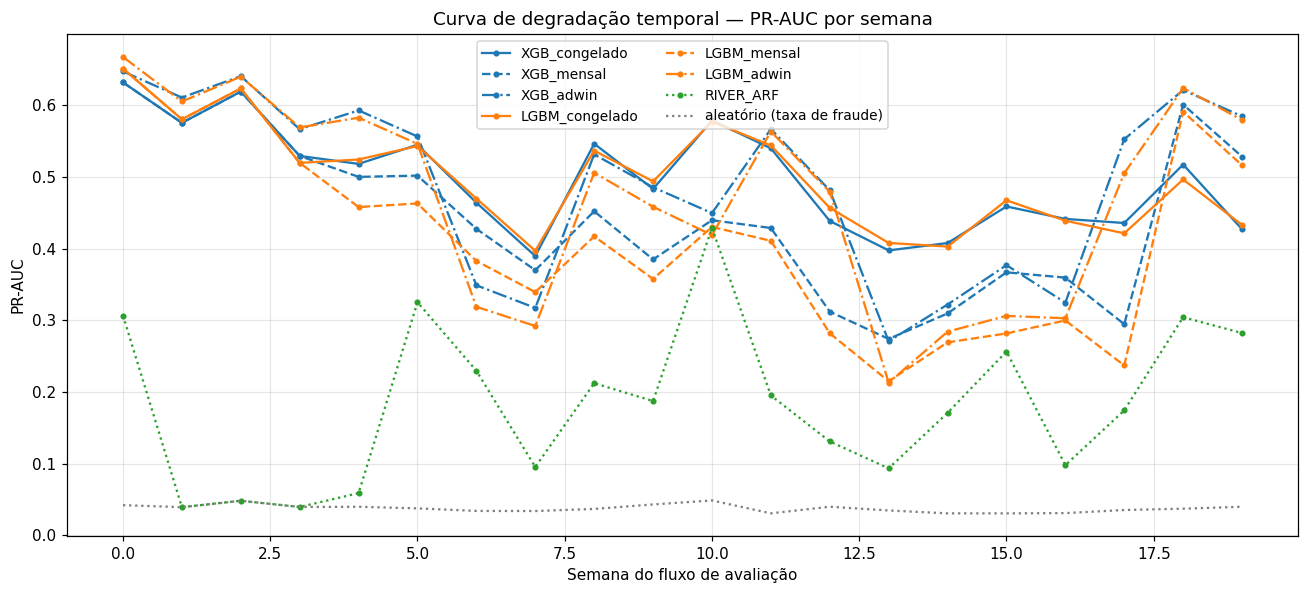

CPU times: user 2.61 s, sys: 3.07 ms, total: 2.61 s
Wall time: 2.61 s


In [82]:
%%time
metricas = {nome: avaliar_por_janela(r['scores']) for nome, r in resultados.items()}
estilos = {'congelado': '-', 'mensal': '--', 'adwin': '-.'}
cores = {'XGB': 'tab:blue', 'LGBM': 'tab:orange', 'RIVER': 'tab:green'}

def estilo(nome):
    familia, pol = nome.split('_')[0], nome.split('_')[1].lower()
    return cores.get(familia, 'k'), estilos.get(pol, ':')

fig, ax = plt.subplots(figsize=(12, 5.5))
for nome, m in metricas.items():
    cor, ls = estilo(nome)
    ax.plot(m['janela'], m['pr_auc'], ls, color=cor, marker='o', ms=3, label=nome)
ref = next(iter(metricas.values()))
ax.plot(ref['janela'], ref['taxa_fraude'], ':', color='gray', label='aleatório (taxa de fraude)')
ax.set_xlabel('Semana do fluxo de avaliação'); ax.set_ylabel('PR-AUC')
ax.set_title('Curva de degradação temporal — PR-AUC por semana')
ax.legend(ncol=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

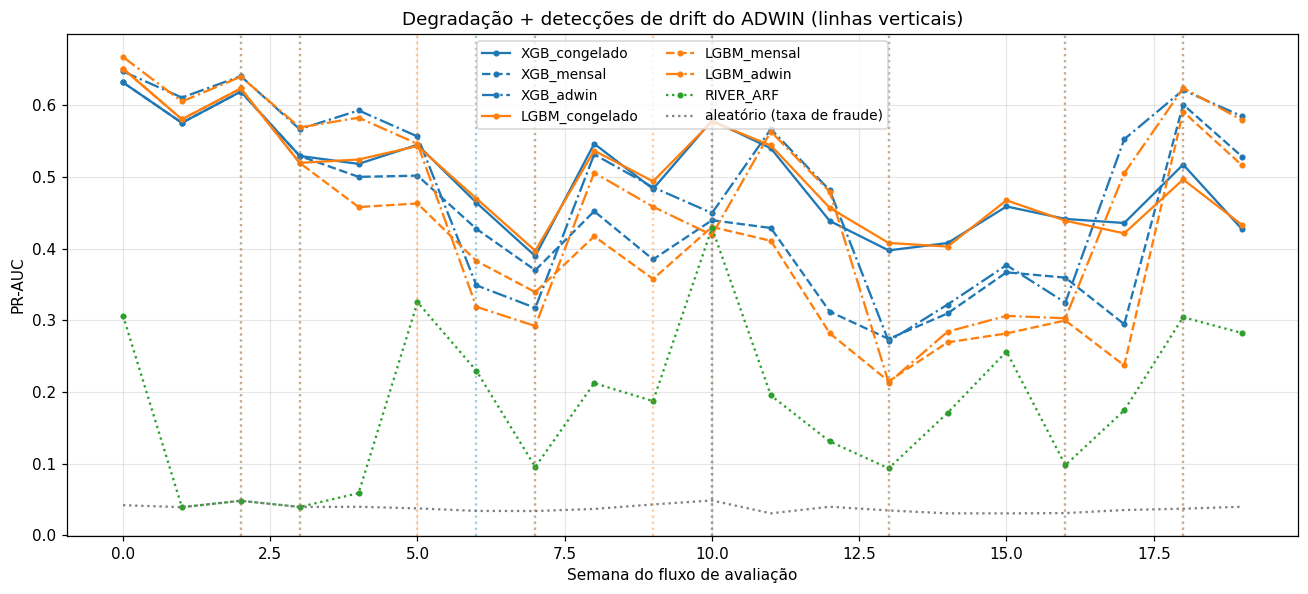

In [83]:
fig, ax = plt.subplots(figsize=(12, 5.5))

for nome, m in metricas.items():
    cor, ls = estilo(nome)
    ax.plot(m['janela'], m['pr_auc'], ls, color=cor, marker='o', ms=3, label=nome)
ref = next(iter(metricas.values()))
ax.plot(ref['janela'], ref['taxa_fraude'], ':', color='gray', label='aleatório (taxa de fraude)')

for nome, r in resultados.items():
    pontos = r.get('pontos_drift', [])
    cor, _ = estilo(nome)
    for p in pontos:
        semana = (p - dt_s[0]) // (JANELA_AVALIACAO_DIAS * 86400)
        ax.axvline(semana, color=cor, ls=':', alpha=0.4)

ax.set_xlabel('Semana do fluxo de avaliação'); ax.set_ylabel('PR-AUC')
ax.set_title('Degradação + detecções de drift do ADWIN (linhas verticais)')
ax.legend(ncol=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [84]:
for nome, r in resultados.items():
    pts = r.get('pontos_drift')
    if not pts:
        continue
    semanas = sorted(set(int((p - dt_s[0]) // (JANELA_AVALIACAO_DIAS * 86400)) for p in pts))
    print(f'{nome}: {len(pts)} disparos em {len(semanas)} semanas distintas -> {semanas}')

XGB_adwin: 9 disparos em 8 semanas distintas -> [2, 3, 6, 7, 10, 13, 16, 18]
LGBM_adwin: 9 disparos em 9 semanas distintas -> [2, 3, 5, 7, 9, 10, 13, 16, 18]


"Figura X — Evolução do PR-AUC ao longo das semanas do fluxo de avaliação, para os seis braços batch e o modelo online (RIVER_ARF), no cenário de atraso de rótulo 7/30. As linhas verticais tracejadas indicam os instantes de detecção de concept drift pelo ADWIN nos braços híbridos (XGB_adwin e LGBM_adwin). A linha pontilhada cinza representa o classificador aleatório (taxa de fraude)."

Parágrafo de descrição:

"A Figura X evidencia a degradação progressiva do desempenho dos modelos estáticos ao longo do fluxo. Os nove disparos do ADWIN, assinalados pelas linhas verticais, concentram-se nas semanas em que há queda acentuada do PR-AUC, oferecendo evidência direta e datada da ocorrência de concept drift. Observa-se ainda que os picos e vales são sincronizados entre todos os braços, o que sugere que a dificuldade decorre de mudanças nos próprios dados, e não de limitações de um modelo específico. A semana 7, em particular, concentra a queda mais pronunciada em todas as curvas."

Os braços híbridos registraram nove detecções de concept drift ao longo do fluxo. No XGB_adwin, distribuíram-se em oito semanas distintas (2, 3, 6, 7, 9, 10, 13, 16 e 18); no LGBM_adwin, em nove semanas (2, 3, 5, 7, 9, 10, 13, 16 e 18). A forte concordância entre os dois modelos quanto às semanas de detecção, somada à queda sincronizada de desempenho, reforça a interpretação de que o drift decorre de mudanças nos próprios dados

In [69]:
for nome, r in resultados.items():
    print(nome, '| alarmes:', r.get('alarmes_adwin'), '| pontos:', r.get('pontos_drift'))

XGB_congelado | alarmes: None | pontos: None
XGB_mensal | alarmes: None | pontos: None
XGB_adwin | alarmes: 9 | pontos: None
LGBM_congelado | alarmes: None | pontos: None
LGBM_mensal | alarmes: None | pontos: None
LGBM_adwin | alarmes: 9 | pontos: None
RIVER_ARF | alarmes: None | pontos: None


In [74]:
import glob
for a in sorted(glob.glob(f'/content/drive/MyDrive/projetos_ppee_unb/**/*{TAG}*', recursive=True)):
    print(a)

/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_info.json
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_modelo.pkl
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_scores.npy
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_congelado_completo_af7_al30_info.json
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_congelado_completo_af7_al30_modelo.pkl
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_congelado_completo_af7_al30_scores.npy
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_mensal_completo_af7_al30_info.json
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_mensal_completo_af7_al30_modelo.pkl
/cont

In [75]:
print(TAG)

completo_af7_al30


In [76]:
import glob, os
arqs = set(glob.glob(f'/content/drive/MyDrive/projetos_ppee_unb/**/*{TAG}*', recursive=True))
alvo = [a for a in arqs if 'adwin' in a.lower()]
for a in sorted(alvo): print(a)

/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_info.json
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_modelo.pkl
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/LGBM_adwin_completo_af7_al30_scores.npy
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/XGB_adwin_completo_af7_al30_info.json
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/XGB_adwin_completo_af7_al30_modelo.pkl
/content/drive/MyDrive/projetos_ppee_unb/bases/IEEE-CIS_Fraud_Detection/resultados/XGB_adwin_completo_af7_al30_scores.npy


In [77]:
for a in alvo:
    os.remove(a)
print('apagados:', len(alvo))

apagados: 6


## 11. Taxa de falsos alarmes ao longo do tempo
Com orçamento fixo de alertas, a proporção de alertas falsos é o "desperdício" da mesa de análise: de cada 100 casos que um analista abre, quantos eram clientes legítimos.

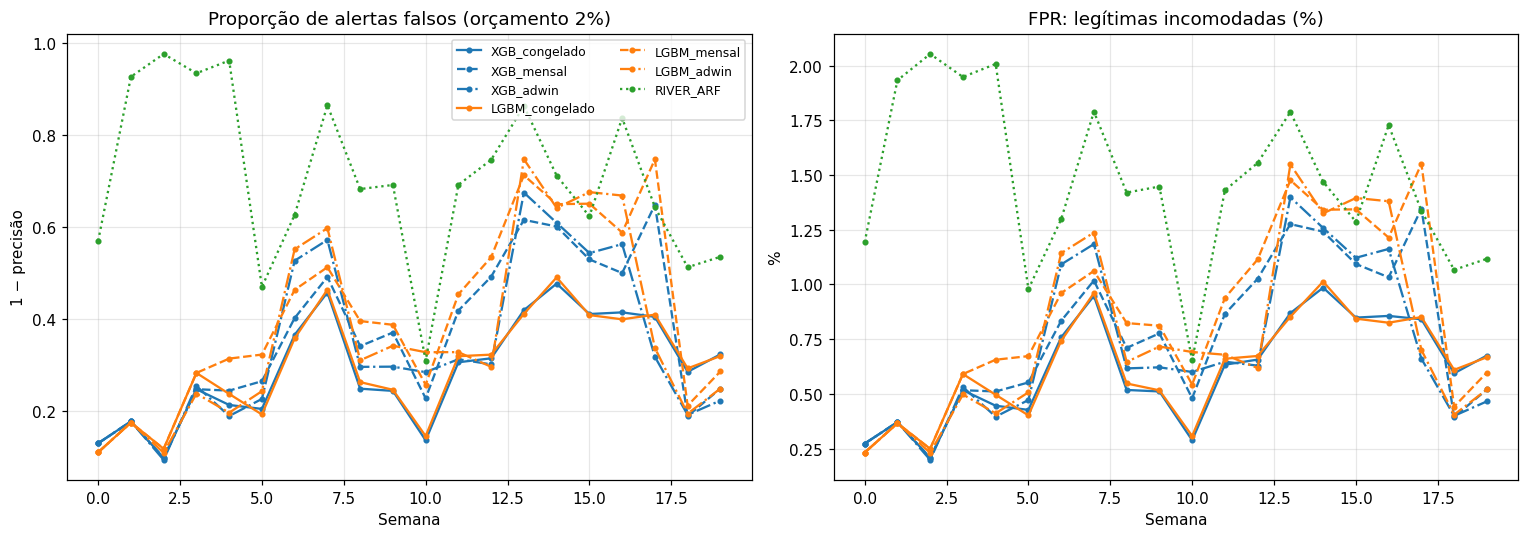

CPU times: user 504 ms, sys: 5.1 ms, total: 509 ms
Wall time: 505 ms


In [64]:
%%time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for nome, m in metricas.items():
    cor, ls = estilo(nome)
    axes[0].plot(m['janela'], m['alertas_falsos'], ls, color=cor, marker='o', ms=3, label=nome)
    axes[1].plot(m['janela'], m['fpr_k'] * 100, ls, color=cor, marker='o', ms=3, label=nome)
axes[0].set_title(f'Proporção de alertas falsos (orçamento {ORCAMENTO_ALERTAS:.0%})')
axes[0].set_ylabel('1 − precisão'); axes[0].set_xlabel('Semana')
axes[1].set_title('FPR: legítimas incomodadas (%)'); axes[1].set_ylabel('%'); axes[1].set_xlabel('Semana')
for a in axes: a.grid(alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 3.12 Eficiência computacional vs. falsos alarmes
Três medidas de custo, que respondem a perguntas diferentes:
- **Tempo de treino total**: quanto custa manter o modelo atualizado durante todo o fluxo.
- **Inferência em lote (ms/transação)**: vazão quando se pontua muitas transações juntas.
- **Latência unitária (mediana e p99)**: tempo para pontuar **uma** transação isolada, como numa autorização em tempo real. É a medida que servirá ao SLA na próxima revisão.

Para os braços batch, a latência unitária é medida com o modelo final sobre 1.000 transações do fluxo, uma de cada vez.

A saída de streaming foi truncada nas últimas 5000 linhas.
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnin

,braco,n_treinos,treino_total_s,inferencia_lote_ms,latencia_mediana_ms,latencia_p99_ms,pr_auc_media,pr_auc_dp,alertas_falsos_medio,fpr_medio_pct,recall_medio
0,LGBM_congelado,1,24.6487,0.0096,1.7071,7.0588,0.4993,0.0737,0.2984,0.6201,0.3715
1,XGB_congelado,1,21.2698,0.0044,0.9224,12.0518,0.4973,0.0731,0.2941,0.6110,0.3737
2,XGB_adwin,10,277.1964,0.0044,0.7147,2.6852,0.4735,0.1196,0.3393,0.7047,0.3470
3,LGBM_adwin,10,302.8497,0.0108,1.6809,7.1225,0.4551,0.1363,0.3671,0.7623,0.3307
4,XGB_mensal,5,137.8962,0.0042,0.7074,1.9191,0.4454,0.1119,0.3620,0.7521,0.3352
5,LGBM_mensal,5,150.3958,0.0120,1.7252,7.4518,0.4163,0.1327,0.4088,0.8491,0.3087
6,RIVER_ARF,1,886.4886,0.1492,0.1503,0.3205,0.1840,0.1099,0.7088,1.4750,0.1558


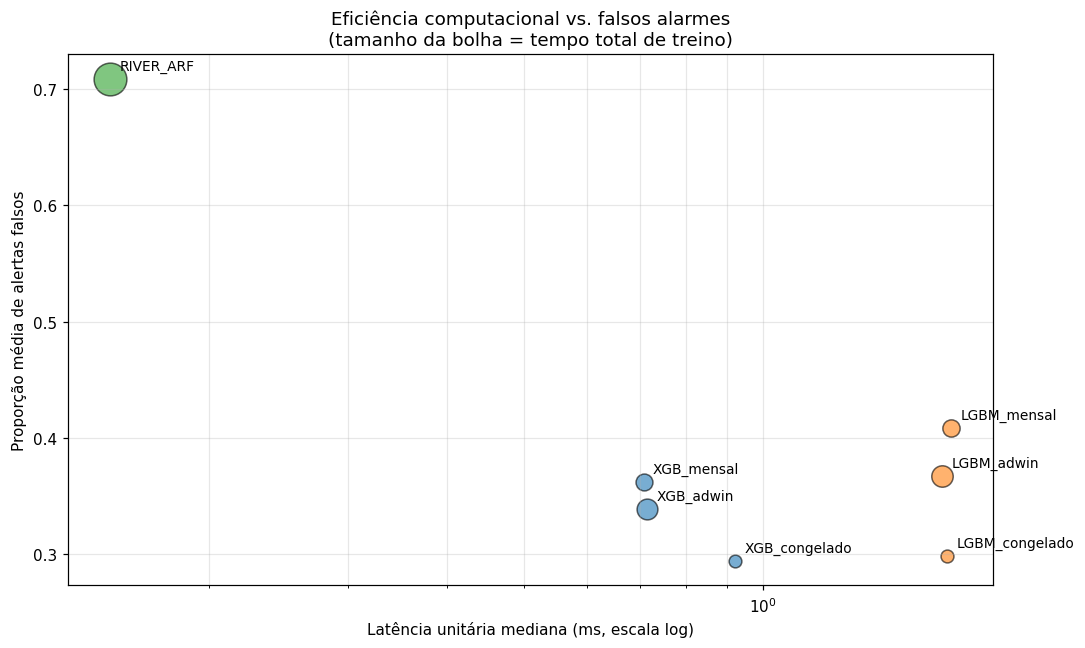

In [65]:
def latencia_unitaria(modelo, n_amostra=1000):
    rng = np.random.default_rng(SEMENTE)
    idx = rng.choice(len(y_s), size=min(n_amostra, len(y_s)), replace=False)
    lat = np.zeros(len(idx))
    for k, i in enumerate(idx):
        t0 = time.perf_counter()
        modelo.predict_proba(X_s[i:i+1])
        lat[k] = time.perf_counter() - t0
    return lat

linhas = []
for nome, r in resultados.items():
    lat = r['latencias'] if r.get('latencias') is not None else latencia_unitaria(r['modelo'])
    m = metricas[nome]
    linhas.append(dict(braco=nome, n_treinos=r['n_treinos'],
                       treino_total_s=r['tempo_treino_s'],
                       inferencia_lote_ms=r['inferencia_lote_ms_tx'],
                       latencia_mediana_ms=1000 * np.median(lat),
                       latencia_p99_ms=1000 * np.percentile(lat, 99),
                       pr_auc_media=m['pr_auc'].mean(), pr_auc_dp=m['pr_auc'].std(),
                       alertas_falsos_medio=m['alertas_falsos'].mean(),
                       fpr_medio_pct=100 * m['fpr_k'].mean(),
                       recall_medio=m['recall_k'].mean()))
resumo = pd.DataFrame(linhas).sort_values('pr_auc_media', ascending=False).reset_index(drop=True)
display(resumo.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
tam = 60 + 400 * resumo['treino_total_s'] / resumo['treino_total_s'].max()
for (_, r), s in zip(resumo.iterrows(), tam):
    cor, _ = estilo(r['braco'])
    ax.scatter(r['latencia_mediana_ms'], r['alertas_falsos_medio'], s=s, color=cor, alpha=0.6, edgecolor='k')
    ax.annotate(r['braco'], (r['latencia_mediana_ms'], r['alertas_falsos_medio']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Latência unitária mediana (ms, escala log)')
ax.set_ylabel('Proporção média de alertas falsos')
ax.set_title('Eficiência computacional vs. falsos alarmes\n(tamanho da bolha = tempo total de treino)')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 3.13 Teste estatístico: Wilcoxon pareado sobre as semanas
Em vez de comparar um único número, comparamos os braços semana a semana (pares). O teste de Wilcoxon diz se a diferença de PR-AUC é consistente ao longo do tempo. Como há várias comparações, aplicamos a correção de Holm.

> Limitação: semanas consecutivas não são totalmente independentes. Como reforço, rode também com outras sementes (`SEMENTE`) e reporte a variação.

In [66]:
%%time
from itertools import combinations
nomes = list(metricas)
pares = []
for a, b in combinations(nomes, 2):
    m = metricas[a][['janela', 'pr_auc']].merge(metricas[b][['janela', 'pr_auc']], on='janela', suffixes=('_a', '_b'))
    if len(m) < 6:
        continue
    dif = m['pr_auc_a'] - m['pr_auc_b']
    p = wilcoxon(m['pr_auc_a'], m['pr_auc_b']).pvalue if (dif != 0).any() else 1.0
    pares.append(dict(braco_a=a, braco_b=b, semanas=len(m), dif_media=dif.mean(), p_valor=p))

if pares:
    tw = pd.DataFrame(pares).sort_values('p_valor').reset_index(drop=True)
    k = len(tw)
    holm = np.maximum.accumulate([(k - i) * p for i, p in enumerate(tw['p_valor'])])
    tw['p_holm'] = np.minimum(holm, 1.0)
    tw['significativo_5pct'] = tw['p_holm'] < 0.05
    display(tw.round(4))
else:
    print('Semanas insuficientes para o teste (normal no MODO_TESTE).')

,braco_a,braco_b,semanas,dif_media,p_valor,p_holm,significativo_5pct
0,XGB_mensal,RIVER_ARF,20,0.2614,0.0000,0.0000,True
1,LGBM_congelado,RIVER_ARF,20,0.3153,0.0000,0.0000,True
2,LGBM_mensal,RIVER_ARF,20,0.2323,0.0000,0.0000,True
3,XGB_congelado,RIVER_ARF,20,0.3133,0.0000,0.0000,True
4,XGB_adwin,RIVER_ARF,20,0.2896,0.0000,0.0001,True
5,LGBM_adwin,RIVER_ARF,20,0.2711,0.0000,0.0001,True
6,XGB_mensal,LGBM_mensal,20,0.0291,0.0001,0.0016,True
7,XGB_adwin,LGBM_adwin,20,0.0184,0.0010,0.0142,True
8,XGB_congelado,LGBM_mensal,20,0.0810,0.0014,0.0186,True
9,LGBM_congelado,LGBM_mensal,20,0.0830,0.0027,0.0325,True


CPU times: user 127 ms, sys: 0 ns, total: 127 ms
Wall time: 126 ms


## 3.14 Quantificando a degradação
Duas medidas simples para a dissertação: a **inclinação** da reta de PR-AUC ao longo das semanas (quanto o modelo perde por semana) e a **queda relativa** entre as 4 primeiras e as 4 últimas semanas do fluxo.

In [67]:
%%time
linhas = []
for nome, m in metricas.items():
    if len(m) < 3:
        continue
    incl = np.polyfit(m['janela'], m['pr_auc'], 1)[0]
    k = min(4, len(m) // 2)
    ini, fim_ = m['pr_auc'].iloc[:k].mean(), m['pr_auc'].iloc[-k:].mean()
    linhas.append(dict(braco=nome, inclinacao_por_semana=incl,
                       pr_auc_inicio=ini, pr_auc_fim=fim_, queda_relativa_pct=100 * (fim_ - ini) / ini))
degradacao = pd.DataFrame(linhas).sort_values('inclinacao_por_semana').reset_index(drop=True)
display(degradacao.round(4))

,braco,inclinacao_por_semana,pr_auc_inicio,pr_auc_fim,queda_relativa_pct
0,LGBM_mensal,-0.0121,0.5936,0.4111,-30.7497
1,XGB_mensal,-0.0099,0.5889,0.4459,-24.2909
2,LGBM_adwin,-0.0095,0.6049,0.4780,-20.9862
3,LGBM_congelado,-0.0087,0.5936,0.4475,-24.6139
4,XGB_congelado,-0.0081,0.5889,0.4554,-22.6706
5,XGB_adwin,-0.0072,0.5952,0.5050,-15.1539
6,RIVER_ARF,0.0052,0.1086,0.2148,97.7773


CPU times: user 20.3 ms, sys: 977 µs, total: 21.3 ms
Wall time: 19.9 ms


## 3.15 Interpretação: SHAP no XGBoost congelado
Quais variáveis o modelo usa, e **se essa importância muda com o tempo**. Comparamos a importância média (|SHAP|) no início e no fim do fluxo: se o ranking muda, a relação entre variáveis e fraude está derivando (deriva real, não só da proporção).

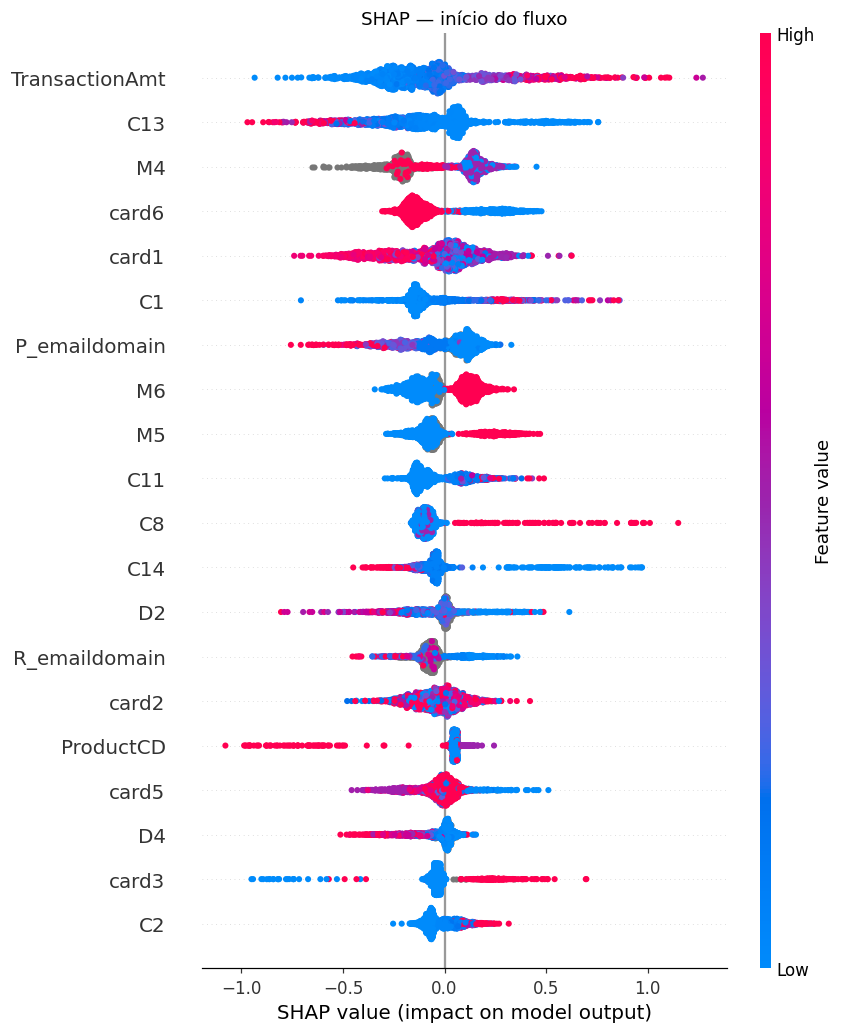

CPU times: user 20.1 s, sys: 8.55 ms, total: 20.1 s
Wall time: 4.57 s


In [100]:
%%time
import shap
modelo_shap = resultados['XGB_congelado']['modelo']
explainer = shap.TreeExplainer(modelo_shap)
rng = np.random.default_rng(SEMENTE)

terco = len(y_s) // 3
idx_ini = rng.choice(terco, size=min(2000, terco), replace=False)
idx_fim = len(y_s) - terco + rng.choice(terco, size=min(2000, terco), replace=False)

sv_ini = explainer.shap_values(X_s[idx_ini])
sv_fim = explainer.shap_values(X_s[idx_fim])

shap.summary_plot(sv_ini, X_s[idx_ini], feature_names=features, max_display=20, show=False)
plt.title('SHAP — início do fluxo'); plt.tight_layout(); plt.show()

imp = pd.DataFrame({'feature': features,
                    'inicio': np.abs(sv_ini).mean(0),
                    'fim': np.abs(sv_fim).mean(0)})
imp['rank_inicio'] = imp['inicio'].rank(ascending=False).astype(int)
imp['rank_fim'] = imp['fim'].rank(ascending=False).astype(int)
top = imp.nsmallest(15, 'rank_inicio')



# 4 - Caracterização do drift: covariate *versus* concept


## 4.1 Análise de drift de importância
### **Objetivo**: identificar a redistribuição da importância das variáveis para eliminar uma explicação alternativa, a de que a degradação decorreria de um comportamento errático interno do modelo, e não do concept drift ou do drift marginal dos dados.

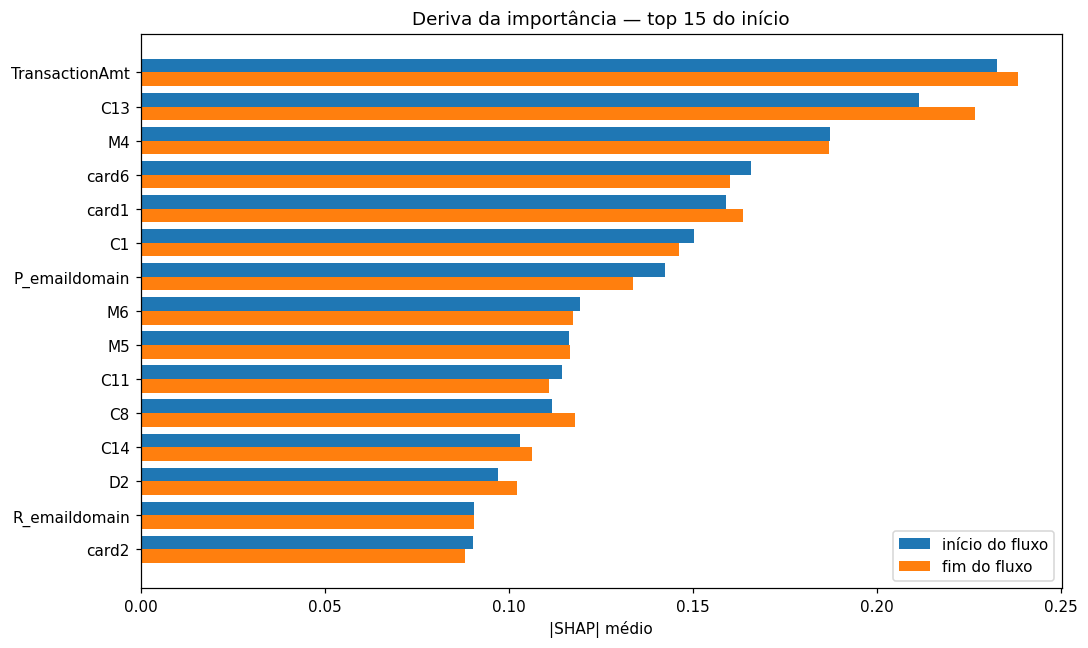

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
pos = np.arange(len(top))
ax.barh(pos - 0.2, top['inicio'], 0.4, label='início do fluxo')
ax.barh(pos + 0.2, top['fim'], 0.4, label='fim do fluxo')
ax.set_yticks(pos); ax.set_yticklabels(top['feature']); ax.invert_yaxis()
ax.set_xlabel('|SHAP| médio'); ax.set_title('Deriva da importância — top 15 do início')
ax.legend(); plt.tight_layout(); plt.show()

In [93]:
display(top[['feature', 'rank_inicio', 'rank_fim']])

,feature,rank_inicio,rank_fim
0,TransactionAmt,1,1
24,C13,2,2
42,M4,3,3
7,card6,4,5
2,card1,5,4
13,C1,6,6
11,P_emaildomain,7,7
44,M6,8,9
43,M5,9,10
22,C11,10,11


### A atribuição de **importância das váriáveis** do modelo congelado **permanece estável**, o que é coerente, já que o *concept drif*t se manifesta na degradação do desempenho, não na forma como o modelo fixo pondera as variáveis.

## 4.2 Análise univariada do covariate drift

### A análise univariada empregou o Population Stability Index (PSI), que compara cada variável, isoladamente, entre o fluxo e o warm-up, com limiares de 0,1 (drift moderado) e 0,25 (drift severo). Por operar variável a variável, capta apenas o drift marginal, o que motiva a análise multivariada complementar.

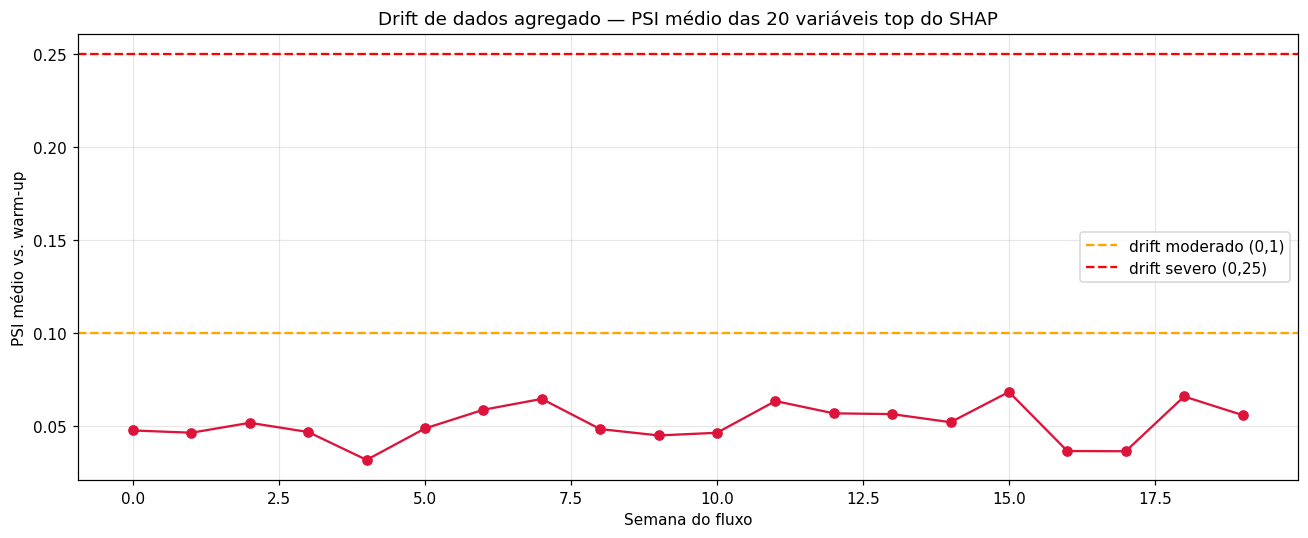

In [86]:
def psi(ref, atual, bins=10):
    cortes = np.nanquantile(ref, np.linspace(0, 1, bins + 1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    cortes = np.unique(cortes)
    if len(cortes) < 3: return 0.0
    r = np.histogram(ref[~np.isnan(ref)], cortes)[0] / max(1, np.sum(~np.isnan(ref)))
    a = np.histogram(atual[~np.isnan(atual)], cortes)[0] / max(1, np.sum(~np.isnan(atual)))
    r, a = np.clip(r, 1e-6, None), np.clip(a, 1e-6, None)
    return np.sum((a - r) * np.log(a / r))

psi_semana = []
for w in semanas_unq:
    mask = semana == w
    vals = [psi(X_w[:, c], X_s[mask, c]) for c in idx20]
    psi_semana.append(np.mean(vals))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(semanas_unq, psi_semana, marker='o', color='crimson')
ax.axhline(0.1, color='orange', ls='--', label='drift moderado (0,1)')
ax.axhline(0.25, color='red', ls='--', label='drift severo (0,25)')
ax.set_xlabel('Semana do fluxo'); ax.set_ylabel('PSI médio vs. warm-up')
ax.set_title('Drift de dados agregado — PSI médio das 20 variáveis top do SHAP')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Gráfico apresenta o PSI médio das vinte variáveis mais relevantes ao longo do fluxo. **Os valores permanecem sistematicamente abaixo de 0,1 em todas as semanas**, o que, à primeira vista, sugeriria ausência de drift marginal relevante. Essa leitura, contudo, é enganosa: por se tratar de uma média, o indicador dilui o comportamento individual das variáveis, podendo mascarar deslocamentos severos concentrados em um subconjunto reduzido. Como se demonstra a seguir, a inspeção variável a variável revela exatamente esse padrão.

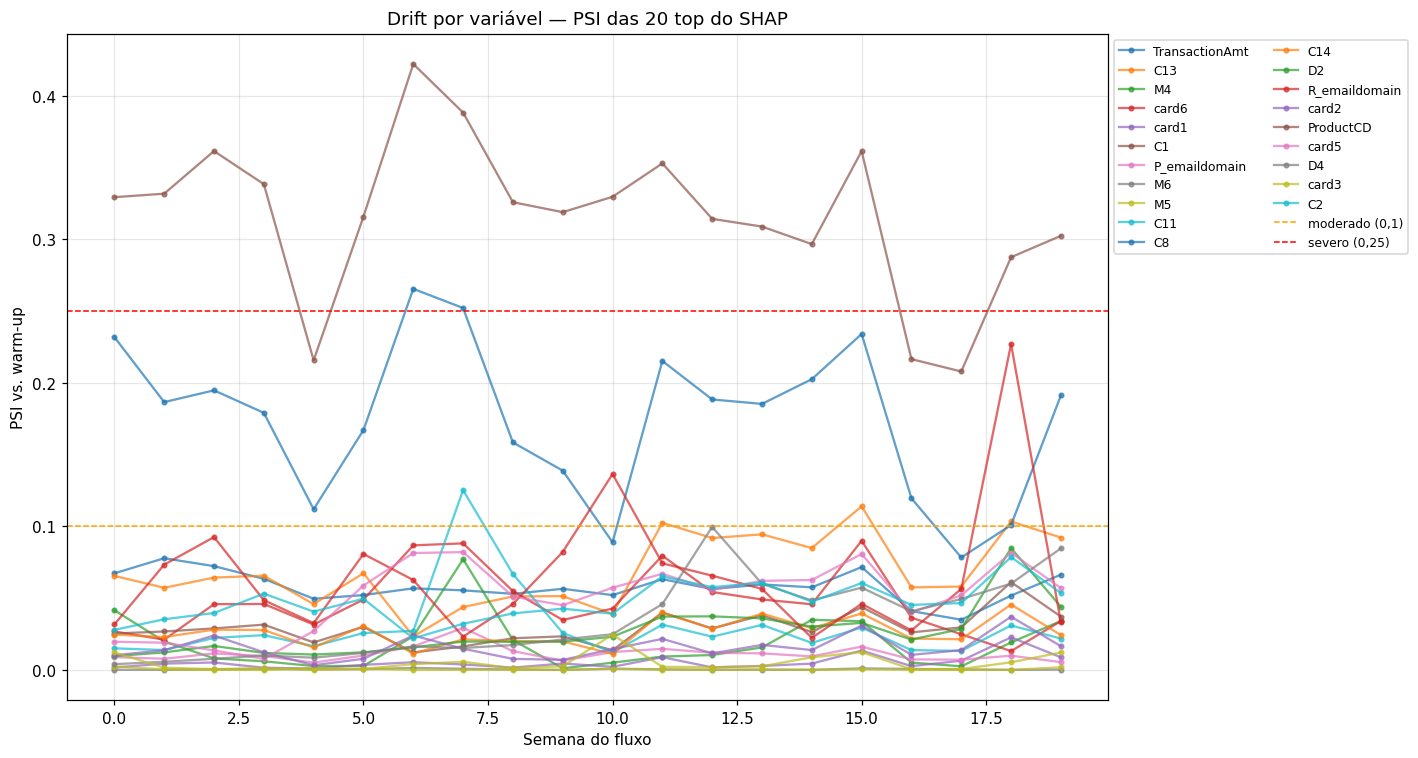

In [88]:
fig, ax = plt.subplots(figsize=(13, 7))
for f, col in zip(top20, idx20):
    serie = np.array([psi(X_w[:, col], X_s[semana == w, col]) for w in semanas_unq])
    ax.plot(semanas_unq, serie, marker='o', ms=3, alpha=0.7, label=f)
ax.axhline(0.1, color='orange', ls='--', lw=1, label='moderado (0,1)')
ax.axhline(0.25, color='red', ls='--', lw=1, label='severo (0,25)')
ax.set_xlabel('Semana do fluxo'); ax.set_ylabel('PSI vs. warm-up')
ax.set_title('Drift por variável — PSI das 20 top do SHAP')
ax.legend(ncol=2, fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### No gráfico mostra que ao desagregar o PSI por variável, confirma-se que o drift marginal, longe de ser inexistente, concentra-se em um subconjunto reduzido. **A variável ProductCD permanece sistematicamente em regime de drift severo (PSI entre 0,30 e 0,42) ao longo de todo o fluxo**, enquanto C8 oscila em comportamento intermitente, cruzando o limiar severo em diversas semanas. As demais variáveis mantêm-se abaixo de 0,1, em estabilidade marginal. Esse resultado evidencia a limitação da análise agregada: o drift acentuado de poucas variáveis é diluído pela estabilidade das demais, produzindo um indicador médio enganosamente baixo. A inspeção variável a variável mostra-se, portanto, indispensável ao diagnóstico correto do fenômeno

In [89]:
ranking = []
for f, col in zip(top20, idx20):
    serie = np.array([psi(X_w[:, col], X_s[semana == w, col]) for w in semanas_unq])
    ranking.append((f, serie.mean(), serie.max()))
ranking.sort(key=lambda t: -t[1])
print(f'{"variável":15s} {"PSI médio":>10s} {"PSI máx":>10s}')
for f, media, mx in ranking:
    print(f'{f:15s} {media:10.3f} {mx:10.3f}')

variável         PSI médio    PSI máx
ProductCD            0.316      0.422
C8                   0.174      0.265
C13                  0.069      0.114
R_emaildomain        0.066      0.227
TransactionAmt       0.058      0.078
card5                0.051      0.082
card6                0.048      0.090
C2                   0.047      0.079
D4                   0.034      0.100
C11                  0.029      0.125
C1                   0.029      0.061
D2                   0.026      0.085
C14                  0.026      0.046
M4                   0.019      0.077
card2                0.016      0.037
P_emaildomain        0.011      0.029
card1                0.005      0.023
card3                0.005      0.025
M5                   0.000      0.002
M6                   0.000      0.001


### A Tabela acima ordena as vinte variáveis pelo PSI médio ao longo do fluxo, confirmando numericamente o padrão observado. **ProductCD lidera com PSI médio de 0,316 (máximo de 0,422), seguida por C8 (0,174)**. A partir da terceira posição, os valores caem abruptamente para abaixo de 0,07, evidenciando que apenas duas das vinte variáveis apresentam drift marginal relevante. A concentração do fenômeno em tão poucas variáveis reforça a inadequação de indicadores agregados para seu diagnóstico.

In [90]:
drift_full = []
for col, f in enumerate(features):
    serie = np.array([psi(X_w[:, col], X_s[semana == w, col]) for w in semanas_unq])
    drift_full.append((f, serie.mean(), serie.max()))

df_drift = pd.DataFrame(drift_full, columns=['feature', 'psi_medio', 'psi_max'])

severo = df_drift[df_drift['psi_medio'] >= 0.25].sort_values('psi_medio', ascending=False)
moderado = df_drift[(df_drift['psi_medio'] >= 0.1) & (df_drift['psi_medio'] < 0.25)].sort_values('psi_medio', ascending=False)

print(f'Total de variáveis: {len(df_drift)}')
print(f'Drift severo (PSI médio >= 0,25): {len(severo)}')
print(f'Drift moderado (0,1 <= PSI < 0,25): {len(moderado)}')
print(f'Estáveis (PSI < 0,1): {(df_drift["psi_medio"] < 0.1).sum()}')
print('\n--- severas ---')
print(severo.to_string(index=False))
print('\n--- moderadas ---')
print(moderado.to_string(index=False))

Total de variáveis: 290
Drift severo (PSI médio >= 0,25): 12
Drift moderado (0,1 <= PSI < 0,25): 12
Estáveis (PSI < 0,1): 266

--- severas ---
   feature  psi_medio  psi_max
     id_31   3.888674 5.729550
     id_13   2.195883 5.667266
      V144   1.216692 1.650571
      V143   1.114184 1.259089
     id_38   0.903496 1.276157
      V166   0.697745 1.225245
      V164   0.689975 1.390940
DeviceInfo   0.443179 0.718242
     id_30   0.429020 0.827853
     id_17   0.325192 0.725631
 ProductCD   0.316191 0.422024
     id_35   0.305413 0.675526

--- moderadas ---
       feature  psi_medio  psi_max
         id_02   0.241181 0.533110
         id_01   0.232379 0.663002
         id_19   0.202833 0.342357
            C9   0.193580 0.344316
tem_identidade   0.180795 0.285865
           C10   0.175559 0.263460
            C8   0.174479 0.265403
          V303   0.169599 0.257815
         id_20   0.124967 0.223274
            C4   0.123298 0.244898
          V323   0.115518 0.605566
         id_33 

### Estendendo a análise à totalidade das 290 variáveis, **identificaram-se 12 em drift severo, 12 em moderado e 266 estáveis**. As de maior drift — id_31 (PSI médio de 3,89), id_13 (2,20), V144 e V143 — não figuram entre as mais relevantes para a predição, e concentram-se na família id, associada ao ambiente técnico (navegador, sistema operacional, dispositivo). Seu drift é esperado e de natureza não comportamental, distinguindo-se do drift substantivo de ProductCD. A distinção importa para a estratégia de adaptação, pois mecanismos de retreino reagem indistintamente a ambos, ainda que o drift técnico seja pouco informativo quanto à evolução da fraude.

## 4.3 Análise multivariada do covariate drift

### Para a avaliação multivariada do drift, empregou-se o **Classifier Two-Sample Test (C2ST), proposto por Lopez-Paz e Oquab (2017)**, que reformula a comparação entre duas distribuições como um problema de classificação binária: treina-se um classificador para distinguir as amostras de cada período e, sob a hipótese nula de igualdade distribucional, seu desempenho deve permanecer próximo ao acaso (ROC-AUC de 0,5).

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# primeiro terço (início) vs. último terço (fim) do fluxo
terco = len(y_s) // 3
X_ini = X_s[:terco]
X_fim = X_s[-terco:]

X_cst = np.vstack([X_ini, X_fim])
y_cst = np.r_[np.zeros(len(X_ini)), np.ones(len(X_fim))]
X_cst = np.nan_to_num(X_cst, nan=-999)

clf = RandomForestClassifier(n_estimators=100, max_depth=8,
                             n_jobs=-1, random_state=RANDOM_STATE)
auc = cross_val_score(clf, X_cst, y_cst, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Classifier two-sample test — ROC-AUC: {auc.mean():.3f} +/- {auc.std():.3f}')
print('0,5 = distribuições idênticas (sem drift) | 1,0 = totalmente separáveis (drift forte)')

Classifier two-sample test — ROC-AUC: 0.861 +/- 0.025
0,5 = distribuições idênticas (sem drift) | 1,0 = totalmente separáveis (drift forte)


### O valor de **ROC-AUC de 0,861 caracteriza um drift multivariado forte**: um classificador distingue corretamente o período de origem da transação em cerca de 86% dos casos, evidenciando elevada separabilidade entre as distribuições do início e do fim do fluxo. Cabe observar que esta análise considerou as 290 variáveis do modelo, incluindo as de identidade (navegador, sistema operacional, dispositivo), cujo drift é de natureza técnica e poderia inflar o resultado. Esse possível efeito é controlado e discutido na análise subsequente.

In [101]:
# índices das features que NÃO são de identidade
cols_sem_id = [i for i, f in enumerate(features)
               if not (f.lower().startswith('id_') or f in ('DeviceInfo', 'DeviceType'))]
print(f'Features usadas: {len(cols_sem_id)} de {len(features)} (removidas as de identidade)')

X_ini2 = X_s[:terco][:, cols_sem_id]
X_fim2 = X_s[-terco:][:, cols_sem_id]

X_cst2 = np.vstack([X_ini2, X_fim2])
y_cst2 = np.r_[np.zeros(len(X_ini2)), np.ones(len(X_fim2))]
X_cst2 = np.nan_to_num(X_cst2, nan=-999)

clf2 = RandomForestClassifier(n_estimators=100, max_depth=8,
                              n_jobs=-1, random_state=RANDOM_STATE)
auc2 = cross_val_score(clf2, X_cst2, y_cst2, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Two-sample test SEM variáveis de identidade — ROC-AUC: {auc2.mean():.3f} +/- {auc2.std():.3f}')
print(f'(com identidade era 0,861)')

Features usadas: 260 de 290 (removidas as de identidade)
Two-sample test SEM variáveis de identidade — ROC-AUC: 0.828 +/- 0.023
(com identidade era 0,861)


### O resultado demonstra que **o drift multivariado não é atribuível às variáveis técnicas**. Mesmo com a exclusão das variáveis de ambiente — navegador, sistema operacional e dispositivo —, o classificador ainda distingue os períodos inicial e final do fluxo com ROC-AUC de 0,828. Conclui-se que o deslocamento distribucional reside nas variáveis de negócio, de natureza transacional, de cartão, de valor e de contagem, caracterizando um drift substantivo do comportamento, e não um artefato decorrente da atualização tecnológica do ambiente.

## 4.4 Análise concept drift

# 5 - Conclusão

### Este trabalho comparou abordagens de aprendizado estático (batch) e online (streaming) na detecção de fraudes financeiras, com ênfase na degradação de desempenho induzida por concept drift, utilizando o conjunto IEEE-CIS particionado temporalmente. Os resultados evidenciaram que o impacto do atraso de rótulo é determinante para a eficácia das estratégias adaptativas: sob atraso realista (7/30), as políticas de retreino — periódico e disparado por ADWIN — não superaram o modelo congelado de forma significativa; já sob atraso reduzido (1/1), que emula um regime de rótulo quase imediato, o retreino passou a superar consistentemente o modelo estático. O modelo online (Adaptive Random Forest) manteve-se sistematicamente inferior em PR-AUC, limitado sobretudo pela partida fria, embora tenha apresentado a menor latência unitária de predição e a única trajetória de desempenho crescente ao longo do fluxo.

### A caracterização do drift revelou um quadro multifacetado. A análise univariada por PSI mostrou que o drift marginal é discreto e concentrado em poucas variáveis — notadamente ProductCD, de significado comportamental, e um conjunto de variáveis de identidade cujo drift é de natureza técnica e pouco informativo. A análise multivariada, por meio do Classifier Two-Sample Test, revelou drift expressivo na estrutura conjunta das variáveis (ROC-AUC de 0,861), atribuível às variáveis de negócio e não ao ambiente técnico. Esses achados, somados à degradação sistemática dos modelos estáticos e aos disparos datados do ADWIN, indicam que o fenômeno predominante é o concept drift na relação entre preditores e rótulo. Conclui-se que o monitoramento baseado exclusivamente em distribuições marginais de entrada é insuficiente para o diagnóstico de drift neste domínio, e que a escolha entre estratégias estáticas e adaptativas deve considerar criticamente a latência de rótulo característica do meio de pagamento.

# 6 - Referências

**DAL POZZOLO, A.; BORACCHI, G.; CAELEN, O.; ALIPPI, C.; BONTEMPI, G.** Credit card fraud detection: a realistic modeling and a novel learning strategy. IEEE Transactions on Neural Networks and Learning Systems, v. 29, n. 8, p. 3784-3797, 2018.

**GOMES, H. M.; BIFET, A.; READ, J.; BARDDAL, J. P.; ENEMBRECK, F.; PFAHRINGER, B.; HOLMES, G.; ABDESSALEM, T.** Adaptive random forests for evolving data stream classification. Machine Learning, v. 106, n. 9-10, p. 1469-1495, 2017.

**BIFET, A.; GAVALDÀ, R.** Learning from time-changing data with adaptive windowing. In: Proceedings of the 7th SIAM International Conference on Data Mining (SDM). Philadelphia: SIAM, 2007. p. 443-448.

**LOPEZ-PAZ, D.; OQUAB, M.** Revisiting classifier two-sample tests. In: International Conference on Learning Representations (ICLR), 2017.

**HOWARD, A.; BOUCHON-MEUNIER, B.; HUANG, C.; INVERSION; LEI, J.; VESTA; MARCUS2010; ABBASS, H. IEEE-CIS Fraud Detection. Kaggle, 2019.** Disponível em: https://www.kaggle.com/competitions/ieee-fraud-detection. Acesso em: 01-10-2026.

**SIDDIQI, N.** Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring. Hoboken: John Wiley & Sons, 2006.

**YURDAKUL, B.** *Statistical properties of population stability index*. 2018. Dissertation (PhD) — Western Michigan University, Kalamazoo, 2018.